In [234]:
import pandas as pd
import yfinance as yf
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

qfactors_df = pd.read_csv("../data-replication/cleaned_public/QFactors_aligned.csv")
inter_df = pd.read_csv("../data-replication/cleaned_public/Intermediary_aligned.csv")
ff5_df = pd.read_csv("../data-replication/cleaned_public/FF5_aligned.csv")
qmj_df = pd.read_csv("../data-replication/cleaned_public/AQR_aligned_QMJ.csv")
umd_df = pd.read_csv("../data-replication/cleaned_public/FF_aligned_UMD.csv")
qfactors_df.set_index("Date", inplace=True)
inter_df.set_index("Date", inplace=True)
ff5_df.set_index("Date", inplace=True)
qmj_df.set_index("Date", inplace=True)
umd_df.set_index("Date", inplace=True)

In [235]:
rmw = ff5_df["RMW"]
inter = inter_df["Intermediary"]
hxz_ia = qfactors_df["HXZ_IA"]
hxz_roe = qfactors_df["HXZ_ROE"]
qmj = qmj_df["QMJ"]
umd = umd_df["UMD"]

In [191]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Ensure Date index is datetime
if not isinstance(rmw.index, pd.DatetimeIndex):
    rmw.index = pd.to_datetime(rmw.index)

# Get risk-free rate for Sharpe calculation
rf = ff5_df['RF']

# Calculate cumulative returns (assuming $1 initial investment)
cumulative_returns = (1 + rmw).cumprod()

# Calculate portfolio value over time
portfolio_value = cumulative_returns

# Calculate statistics
mean_monthly_return = rmw.mean()
std_monthly_return = rmw.std()
mean_rf = rf.mean()

# Annualized statistics (assuming monthly data)
annualized_return = mean_monthly_return * 12
annualized_std = std_monthly_return * np.sqrt(12)
annualized_rf = mean_rf * 12

# Sharpe ratio (annualized)
sharpe_ratio = (annualized_return - annualized_rf) / annualized_std

# Total return
total_return = cumulative_returns.iloc[-1] - 1

# Calculate max drawdown
running_max = cumulative_returns.cummax()
drawdown = (running_max - cumulative_returns) / running_max
max_drawdown = drawdown.max()

# Create results DataFrame
results = pd.DataFrame({
    'Date': rmw.index,
    'RMW_Return': rmw.values,
    'Cumulative_Return': cumulative_returns.values,
    'Portfolio_Value': portfolio_value.values,
    'Running_Max': running_max.values,
    'Drawdown': drawdown.values
})
results.set_index('Date', inplace=True)

print("=" * 70)
print("RMW Factor Backtest Results")
print("=" * 70)
print(f"\nPeriod: {rmw.index[0].strftime('%Y-%m-%d')} to {rmw.index[-1].strftime('%Y-%m-%d')}")
print(f"Number of periods: {len(rmw)}")
print(f"\n--- Performance Statistics ---")
print(f"Mean Monthly Return:     {mean_monthly_return:.4%}")
print(f"Std Monthly Return:      {std_monthly_return:.4%}")
print(f"Mean Risk-Free Rate:     {mean_rf:.4%}")
print(f"\n--- Annualized Statistics ---")
print(f"Annualized Return:       {annualized_return:.4%}")
print(f"Annualized Volatility:   {annualized_std:.4%}")
print(f"Annualized Risk-Free:    {annualized_rf:.4%}")
print(f"\n--- Risk-Adjusted Metrics ---")
print(f"Sharpe Ratio:            {sharpe_ratio:.4f}")
print(f"Max Drawdown:            {max_drawdown:.4%}")
print(f"Total Return:            {total_return:.4%}")
print(f"Final Portfolio Value:   ${portfolio_value.iloc[-1]:.2f} (from $1 initial)")
print("=" * 70)

# Display first and last few rows
print("\nFirst 5 periods:")
print(results.head())
print("\nLast 5 periods:")
print(results.tail())


RMW Factor Backtest Results

Period: 1976-07-30 to 2025-08-29
Number of periods: 590

--- Performance Statistics ---
Mean Monthly Return:     0.3435%
Std Monthly Return:      2.3290%
Mean Risk-Free Rate:     0.3476%

--- Annualized Statistics ---
Annualized Return:       4.1219%
Annualized Volatility:   8.0677%
Annualized Risk-Free:    4.1717%

--- Risk-Adjusted Metrics ---
Sharpe Ratio:            -0.0062
Max Drawdown:            41.7752%
Total Return:            544.2114%
Final Portfolio Value:   $6.44 (from $1 initial)

First 5 periods:
            RMW_Return  Cumulative_Return  Portfolio_Value  Running_Max  \
Date                                                                      
1976-07-30     -0.0103           0.989700         0.989700     0.989700   
1976-08-31     -0.0040           0.985741         0.985741     0.989700   
1976-09-30      0.0098           0.995401         0.995401     0.995401   
1976-10-29     -0.0019           0.993510         0.993510     0.995401   
1976

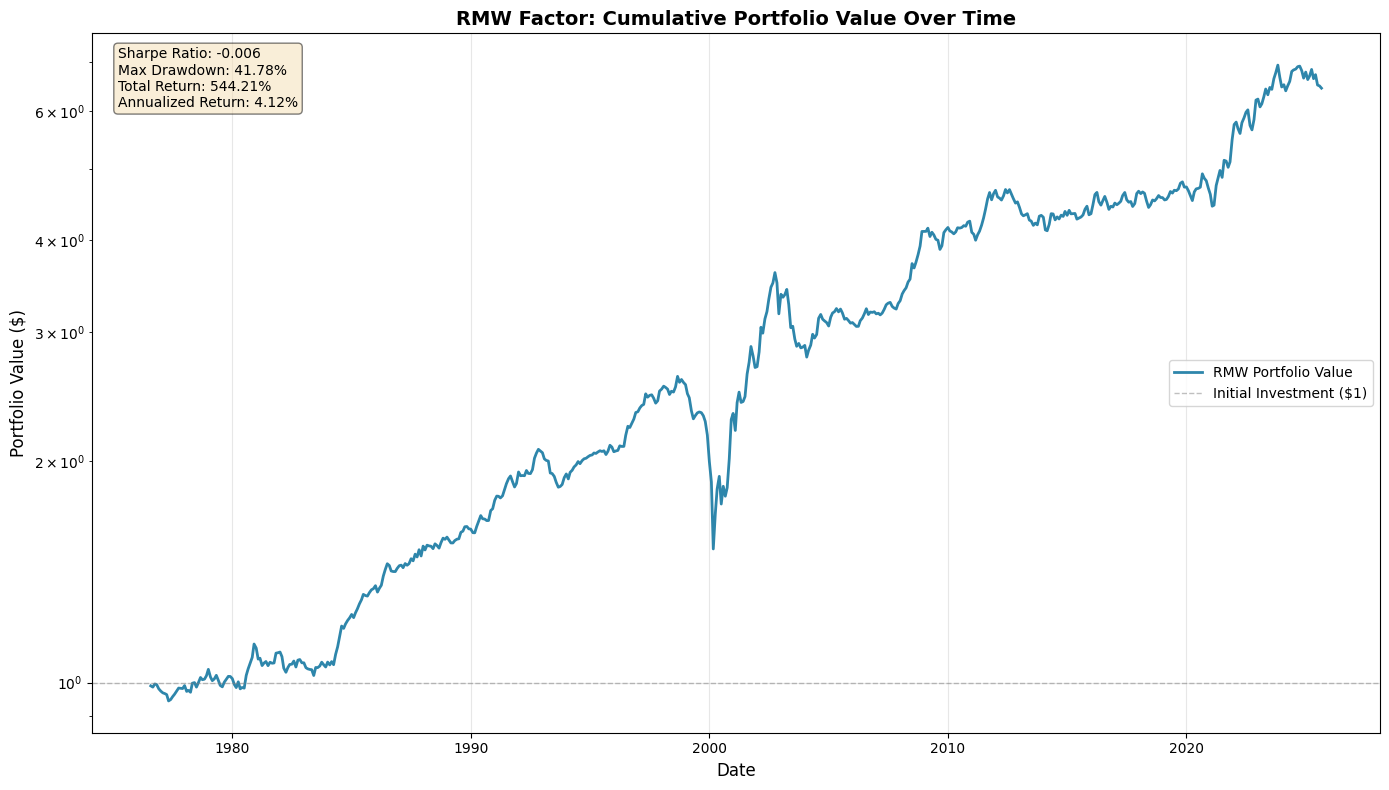

In [192]:
# Create visualization
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

# Plot Cumulative Returns / Portfolio Value
ax.plot(results.index, results['Portfolio_Value'], linewidth=2, color='#2E86AB', label='RMW Portfolio Value')
ax.axhline(y=1, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Initial Investment ($1)')
ax.set_title('RMW Factor: Cumulative Portfolio Value Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Portfolio Value ($)', fontsize=12)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')  # Log scale for better visualization

# Add text box with key metrics
textstr = f'Sharpe Ratio: {sharpe_ratio:.3f}\nMax Drawdown: {max_drawdown:.2%}\nTotal Return: {total_return:.2%}\nAnnualized Return: {annualized_return:.2%}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()


In [193]:
print(f"\nResults DataFrame shape: {results.shape}")
print(f"Columns: {list(results.columns)}")



Results DataFrame shape: (590, 5)
Columns: ['RMW_Return', 'Cumulative_Return', 'Portfolio_Value', 'Running_Max', 'Drawdown']


In [194]:
# Function to run backtest for a specific period
def run_rmw_backtest(rmw_data, rf_data, start_date=None, end_date=None, period_name=""):
    """
    Run RMW backtest for a specific time period
    
    Parameters:
    -----------
    rmw_data : pd.Series
        RMW returns series
    rf_data : pd.Series
        Risk-free rate series
    start_date : str or None
        Start date (e.g., '2000-01-01') or None for beginning
    end_date : str or None
        End date (e.g., '2008-12-31') or None for end
    period_name : str
        Name of the period for display
    
    Returns:
    --------
    dict : Dictionary containing results and statistics
    """
    # Filter data for the period
    if start_date is None:
        start_date = rmw_data.index[0]
    else:
        start_date = pd.to_datetime(start_date)
    
    if end_date is None:
        end_date = rmw_data.index[-1]
    else:
        end_date = pd.to_datetime(end_date)
    
    # Get data for the period
    period_rmw = rmw_data[(rmw_data.index >= start_date) & (rmw_data.index <= end_date)]
    period_rf = rf_data[(rf_data.index >= start_date) & (rf_data.index <= end_date)]
    
    if len(period_rmw) == 0:
        print(f"Warning: No data found for period {period_name}")
        return None
    
    # Calculate cumulative returns
    cumulative_returns = (1 + period_rmw).cumprod()
    portfolio_value = cumulative_returns
    
    # Calculate statistics
    mean_monthly_return = period_rmw.mean()
    std_monthly_return = period_rmw.std()
    mean_rf = period_rf.mean()
    
    # Annualized statistics
    annualized_return = mean_monthly_return * 12
    annualized_std = std_monthly_return * np.sqrt(12)
    annualized_rf = mean_rf * 12
    
    # Sharpe ratio (annualized)
    if annualized_std > 0:
        sharpe_ratio = (annualized_return - annualized_rf) / annualized_std
    else:
        sharpe_ratio = np.nan
    
    # Total return
    total_return = cumulative_returns.iloc[-1] - 1
    
    # Calculate max drawdown
    running_max = cumulative_returns.cummax()
    drawdown = (running_max - cumulative_returns) / running_max
    max_drawdown = drawdown.max()
    
    # Create results DataFrame
    results = pd.DataFrame({
        'Date': period_rmw.index,
        'RMW_Return': period_rmw.values,
        'Cumulative_Return': cumulative_returns.values,
        'Portfolio_Value': portfolio_value.values,
        'Running_Max': running_max.values,
        'Drawdown': drawdown.values
    })
    results.set_index('Date', inplace=True)
    
    # Print results
    print("=" * 70)
    print(f"RMW Factor Backtest Results - {period_name}")
    print("=" * 70)
    print(f"\nPeriod: {period_rmw.index[0].strftime('%Y-%m-%d')} to {period_rmw.index[-1].strftime('%Y-%m-%d')}")
    print(f"Number of periods: {len(period_rmw)}")
    print(f"\n--- Performance Statistics ---")
    print(f"Mean Monthly Return:     {mean_monthly_return:.4%}")
    print(f"Std Monthly Return:      {std_monthly_return:.4%}")
    print(f"Mean Risk-Free Rate:     {mean_rf:.4%}")
    print(f"\n--- Annualized Statistics ---")
    print(f"Annualized Return:       {annualized_return:.4%}")
    print(f"Annualized Volatility:   {annualized_std:.4%}")
    print(f"Annualized Risk-Free:    {annualized_rf:.4%}")
    print(f"\n--- Risk-Adjusted Metrics ---")
    print(f"Sharpe Ratio:            {sharpe_ratio:.4f}")
    print(f"Max Drawdown:            {max_drawdown:.4%}")
    print(f"Total Return:            {total_return:.4%}")
    print(f"Final Portfolio Value:   ${portfolio_value.iloc[-1]:.2f} (from $1 initial)")
    print("=" * 70)
    print()
    
    return {
        'period_name': period_name,
        'results': results,
        'start_date': period_rmw.index[0],
        'end_date': period_rmw.index[-1],
        'mean_monthly_return': mean_monthly_return,
        'std_monthly_return': std_monthly_return,
        'mean_rf': mean_rf,
        'annualized_return': annualized_return,
        'annualized_std': annualized_std,
        'annualized_rf': annualized_rf,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'total_return': total_return,
        'final_value': portfolio_value.iloc[-1]
    }


In [195]:
# Ensure Date index is datetime
if not isinstance(rmw.index, pd.DatetimeIndex):
    rmw.index = pd.to_datetime(rmw.index)
if not isinstance(ff5_df.index, pd.DatetimeIndex):
    ff5_df.index = pd.to_datetime(ff5_df.index)

rf = ff5_df['RF']

# Define periods
periods = [
    {'start': None, 'end': '1999-12-31', 'name': 'Start - 2000'},
    {'start': '2000-01-01', 'end': '2007-12-31', 'name': '2000 - 2008'},
    {'start': '2008-01-01', 'end': '2019-12-31', 'name': '2008 - 2020'},
    {'start': '2020-01-01', 'end': None, 'name': '2020 - End'}
]

# Run backtest for each period
all_results = {}
for period in periods:
    result = run_rmw_backtest(rmw, rf, period['start'], period['end'], period['name'])
    if result is not None:
        all_results[period['name']] = result


RMW Factor Backtest Results - Start - 2000

Period: 1976-07-30 to 1999-12-31
Number of periods: 282

--- Performance Statistics ---
Mean Monthly Return:     0.2575%
Std Monthly Return:      1.5313%
Mean Risk-Free Rate:     0.5608%

--- Annualized Statistics ---
Annualized Return:       3.0902%
Annualized Volatility:   5.3047%
Annualized Risk-Free:    6.7294%

--- Risk-Adjusted Metrics ---
Sharpe Ratio:            -0.6860
Max Drawdown:            23.4543%
Total Return:            99.8291%
Final Portfolio Value:   $2.00 (from $1 initial)

RMW Factor Backtest Results - 2000 - 2008

Period: 2000-01-31 to 2007-12-31
Number of periods: 96

--- Performance Statistics ---
Mean Monthly Return:     0.6176%
Std Monthly Return:      4.2451%
Mean Risk-Free Rate:     0.2659%

--- Annualized Statistics ---
Annualized Return:       7.4112%
Annualized Volatility:   14.7053%
Annualized Risk-Free:    3.1912%

--- Risk-Adjusted Metrics ---
Sharpe Ratio:            0.2870
Max Drawdown:            23.2664%


In [196]:
# Create summary comparison table
summary_data = []
for period_name, result in all_results.items():
    summary_data.append({
        'Period': period_name,
        'Start Date': result['start_date'].strftime('%Y-%m-%d'),
        'End Date': result['end_date'].strftime('%Y-%m-%d'),
        'Annualized Return': f"{result['annualized_return']:.2%}",
        'Annualized Volatility': f"{result['annualized_std']:.2%}",
        'Sharpe Ratio': f"{result['sharpe_ratio']:.3f}",
        'Max Drawdown': f"{result['max_drawdown']:.2%}",
        'Total Return': f"{result['total_return']:.2%}",
        'Final Value ($)': f"${result['final_value']:.2f}"
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "=" * 100)
print("SUMMARY COMPARISON - RMW Backtest Results by Period")
print("=" * 100)
print(summary_df.to_string(index=False))
print("=" * 100)



SUMMARY COMPARISON - RMW Backtest Results by Period
      Period Start Date   End Date Annualized Return Annualized Volatility Sharpe Ratio Max Drawdown Total Return Final Value ($)
Start - 2000 1976-07-30 1999-12-31             3.09%                 5.30%       -0.686       23.45%       99.83%           $2.00
 2000 - 2008 2000-01-31 2007-12-31             7.41%                14.71%        0.287       23.27%       65.62%           $1.66
 2008 - 2020 2008-01-31 2019-12-31             3.13%                 5.57%        0.460       12.12%       42.81%           $1.43
  2020 - End 2020-01-31 2025-08-29             5.86%                 8.90%        0.368        9.65%       36.30%           $1.36


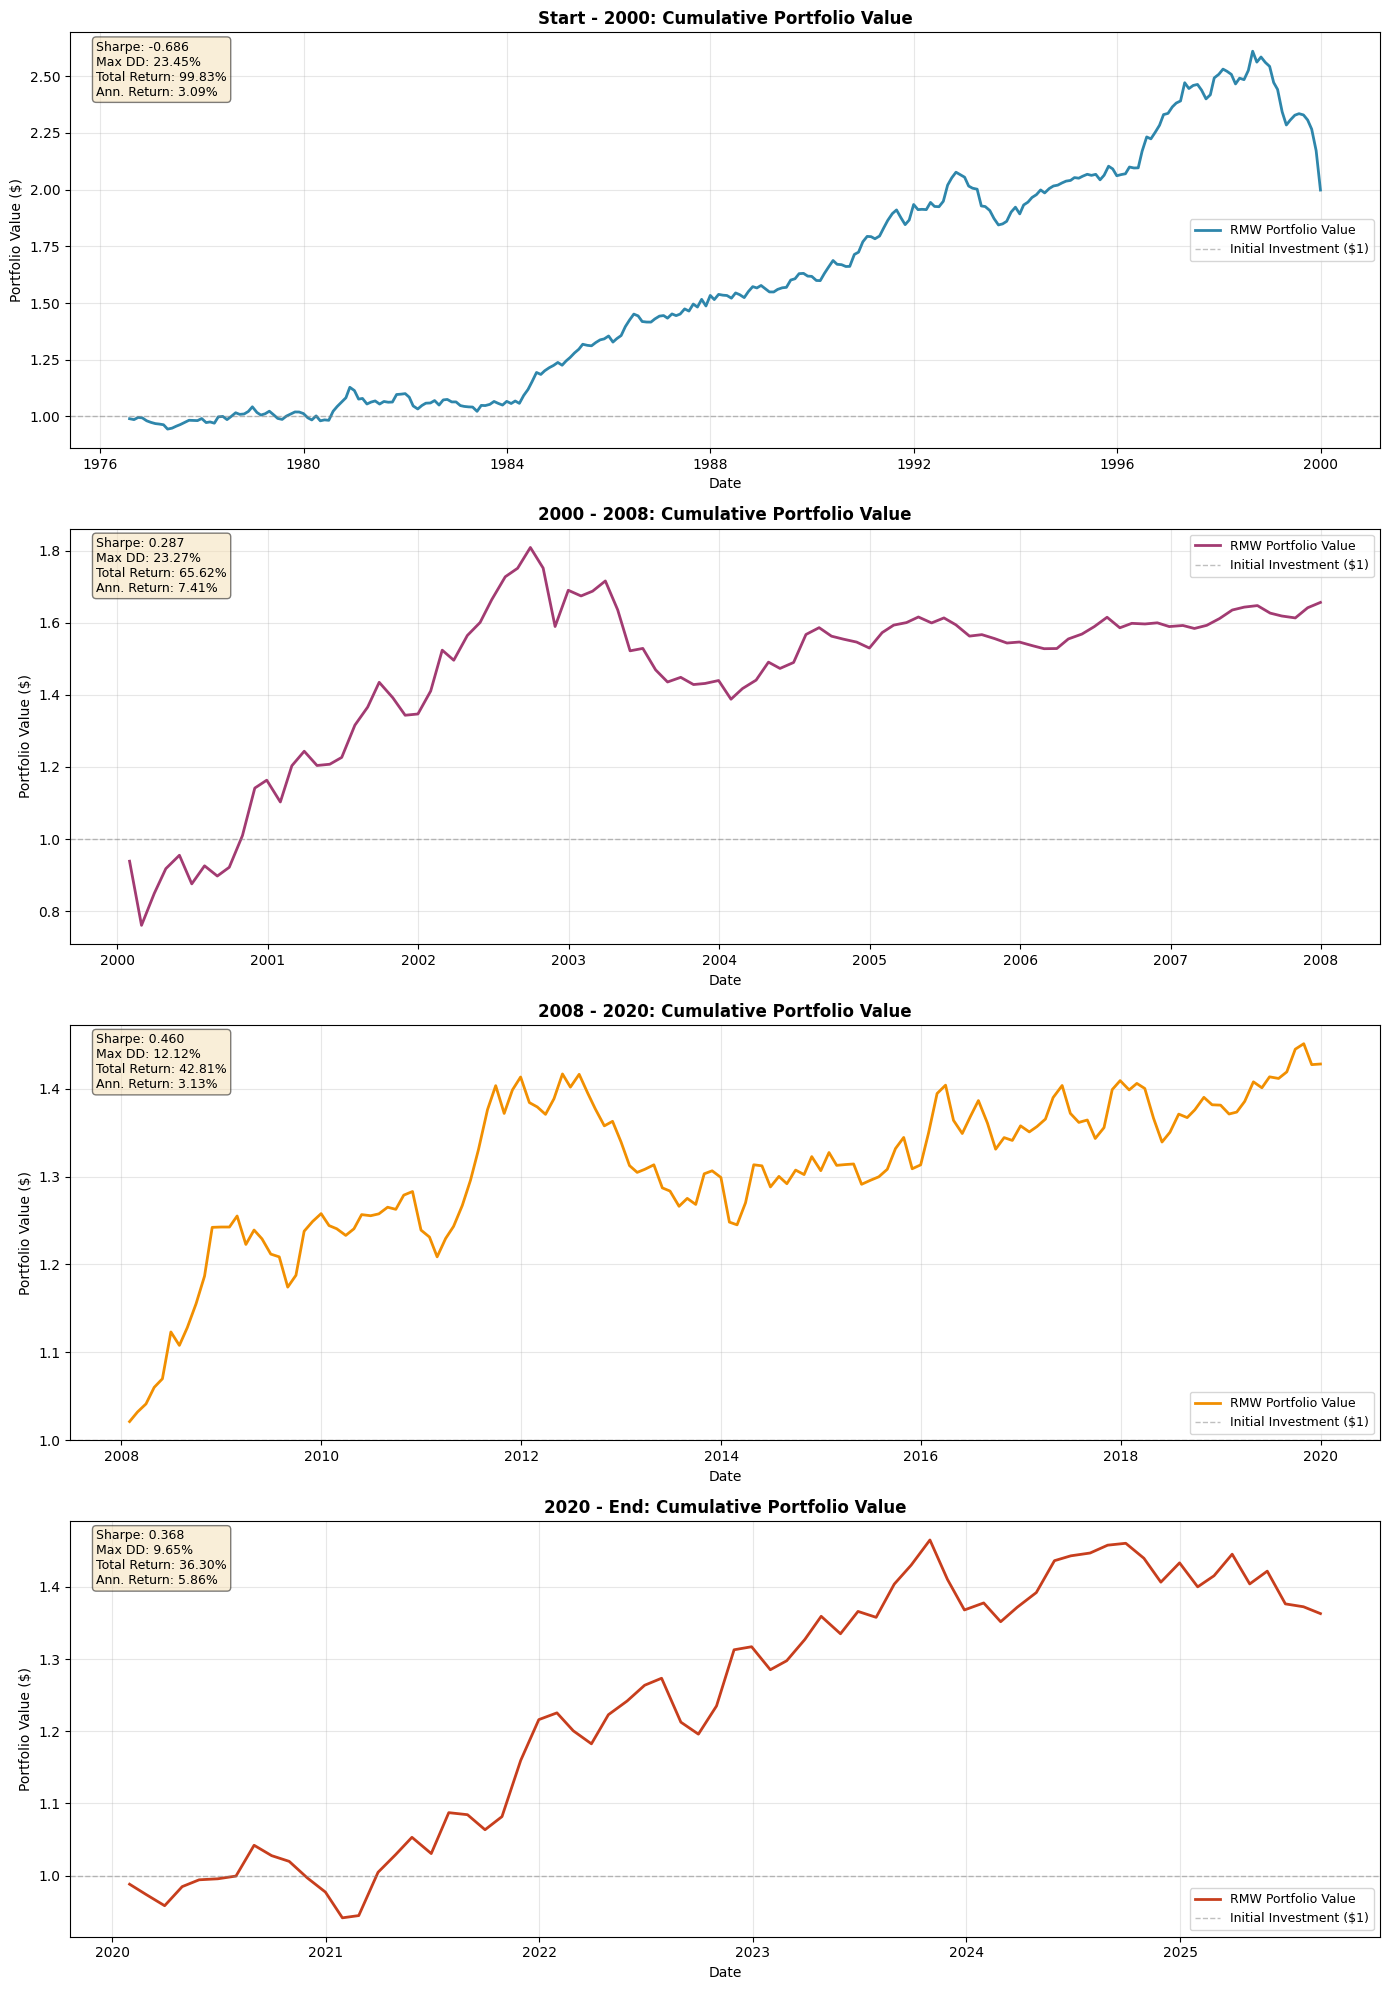

In [197]:
# Create visualizations for each period
n_periods = len(all_results)
fig, axes = plt.subplots(n_periods, 1, figsize=(14, 5 * n_periods))

if n_periods == 1:
    axes = [axes]

colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
period_names = list(all_results.keys())

for idx, (period_name, result) in enumerate(all_results.items()):
    results_df = result['results']
    sharpe = result['sharpe_ratio']
    total_ret = result['total_return']
    ann_ret = result['annualized_return']
    max_dd = result['max_drawdown']
    
    # Plot Cumulative Returns / Portfolio Value
    ax = axes[idx]
    ax.plot(results_df.index, results_df['Portfolio_Value'], 
             linewidth=2, color=colors[idx % len(colors)], label='RMW Portfolio Value')
    ax.axhline(y=1, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Initial Investment ($1)')
    ax.set_title(f'{period_name}: Cumulative Portfolio Value', fontsize=12, fontweight='bold')
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel('Portfolio Value ($)', fontsize=10)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Add text box with key metrics
    textstr = f'Sharpe: {sharpe:.3f}\nMax DD: {max_dd:.2%}\nTotal Return: {total_ret:.2%}\nAnn. Return: {ann_ret:.2%}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=9,
             verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()


In [198]:
# Define start date
start_date = '1976-07-30'
end_date = datetime.now().strftime('%Y-%m-%d')

print("Downloading SPX (S&P 500) data...")
# SPX ticker: ^GSPC or ^SPX
spx_ticker = yf.Ticker("^GSPC")
spx_data = spx_ticker.history(start=start_date, end=end_date)

print("Downloading SPY ETF data...")
# SPY ticker: SPY (ETF, not an index - no ^ prefix)
# SPY started in 1993, so use a later start date
spy_start_date = '1993-01-29'  # SPY launch date
spy_ticker = yf.Ticker("SPY")
spy_data = spy_ticker.history(start=spy_start_date, end=end_date)



print("Downloading Russell 2000 data...")
# Russell 2000 ticker: ^RUT
rut_ticker = yf.Ticker("^RUT")
rut_data = rut_ticker.history(start=start_date, end=end_date)

print(f"\nSPX data shape: {spx_data.shape}")
print(f"Russell 2000 data shape: {rut_data.shape}")
if len(spy_data) > 0:
    print(f"SPY data shape: {spy_data.shape}")
    print(f"\nSPX date range: {spx_data.index[0]} to {spx_data.index[-1]}")
    print(f"Russell 2000 date range: {rut_data.index[0]} to {rut_data.index[-1]}")
    print(f"SPY date range: {spy_data.index[0]} to {spy_data.index[-1]}")
else:
    print(f"SPY data shape: {spy_data.shape} (no data downloaded)")
    print(f"\nSPX date range: {spx_data.index[0]} to {spx_data.index[-1]}")
    print(f"Russell 2000 date range: {rut_data.index[0]} to {rut_data.index[-1]}")
    print("SPY: No data available (check ticker symbol)")



SPX data shape: (12429, 7)
Russell 2000 data shape: (9621, 7)
SPY data shape: (8258, 8)

SPX date range: 1976-07-30 00:00:00-04:00 to 2025-11-17 00:00:00-05:00
Russell 2000 date range: 1987-09-10 00:00:00-04:00 to 2025-11-17 00:00:00-05:00
SPY date range: 1993-01-29 00:00:00-05:00 to 2025-11-17 00:00:00-05:00


In [199]:
# Alternative simpler approach: resample to monthly and get last value
def get_monthly_returns_simple(data, start_date_str='1976-07-30'):
    """
    Get monthly returns using resampling (simpler approach)
    """
    # Remove timezone info from index if present (yfinance returns timezone-aware data)
    if data.index.tz is not None:
        data = data.copy()
        data.index = data.index.tz_localize(None)
    
    # Resample to monthly, taking the last value of each month
    monthly_prices = data['Close'].resample('ME').last()
    
    # Calculate monthly returns
    monthly_returns = monthly_prices.pct_change()
    
    # Filter from start date
    start_date = pd.to_datetime(start_date_str)
    monthly_returns = monthly_returns[monthly_returns.index >= start_date]
    
    # Drop first NaN value (first month has no previous month to calculate return from)
    monthly_returns = monthly_returns.dropna()
    
    return monthly_returns

# Get monthly returns for all three
print("Calculating monthly returns...")
spx_monthly_returns = get_monthly_returns_simple(spx_data, start_date_str=start_date)
rut_monthly_returns = get_monthly_returns_simple(rut_data, start_date_str=start_date)
spy_monthly_returns = get_monthly_returns_simple(spy_data, start_date_str=spy_start_date)

print(f"\nSPX monthly returns: {len(spx_monthly_returns)} months")
print(f"Russell 2000 monthly returns: {len(rut_monthly_returns)} months")
print(f"SPY monthly returns: {len(spy_monthly_returns)} months")
print(f"\nSPX date range: {spx_monthly_returns.index[0]} to {spx_monthly_returns.index[-1]}")
print(f"Russell 2000 date range: {rut_monthly_returns.index[0]} to {rut_monthly_returns.index[-1]}")
print(f"SPY date range: {spy_monthly_returns.index[0]} to {spy_monthly_returns.index[-1]}")


Calculating monthly returns...

SPX monthly returns: 592 months
Russell 2000 monthly returns: 458 months
SPY monthly returns: 394 months

SPX date range: 1976-08-31 00:00:00 to 2025-11-30 00:00:00
Russell 2000 date range: 1987-10-31 00:00:00 to 2025-11-30 00:00:00
SPY date range: 1993-02-28 00:00:00 to 2025-11-30 00:00:00


In [200]:
# Create separate dataframes for SPX, Russell 2000, and SPY
spx_df = pd.DataFrame({
    'Date': spx_monthly_returns.index,
    'SPX_Return': spx_monthly_returns.values
})
spx_df.set_index('Date', inplace=True)

rut_df = pd.DataFrame({
    'Date': rut_monthly_returns.index,
    'RUT_Return': rut_monthly_returns.values
})
rut_df.set_index('Date', inplace=True)

spy_df = pd.DataFrame({
    'Date': spy_monthly_returns.index,
    'SPY_Return': spy_monthly_returns.values
})
spy_df.set_index('Date', inplace=True)

# Display first few rows
print("SPX DataFrame (first 10 rows):")
print(spx_df.head(10))
print("\nRussell 2000 DataFrame (first 10 rows):")
print(rut_df.head(10))
print("\nSPY DataFrame (first 10 rows):")
print(spy_df.head(10))

print(f"\nSPX DataFrame shape: {spx_df.shape}")
print(f"Russell 2000 DataFrame shape: {rut_df.shape}")
print(f"SPY DataFrame shape: {spy_df.shape}")


SPX DataFrame (first 10 rows):
            SPX_Return
Date                  
1976-08-31   -0.005124
1976-09-30    0.022641
1976-10-31   -0.022235
1976-11-30   -0.007775
1976-12-31    0.052498
1977-01-31   -0.050530
1977-02-28   -0.021660
1977-03-31   -0.014025
1977-04-30    0.000203
1977-05-31   -0.023568

Russell 2000 DataFrame (first 10 rows):
            RUT_Return
Date                  
1987-10-31   -0.307652
1987-11-30   -0.055471
1987-12-31    0.078066
1988-01-31    0.040027
1988-02-29    0.086714
1988-03-31    0.044453
1988-04-30    0.020120
1988-05-31   -0.025102
1988-06-30    0.070241
1988-07-31   -0.009319

SPY DataFrame (first 10 rows):
            SPY_Return
Date                  
1993-02-28    0.010669
1993-03-31    0.022399
1993-04-30   -0.025588
1993-05-31    0.026970
1993-06-30    0.003608
1993-07-31   -0.004855
1993-08-31    0.038327
1993-09-30   -0.007276
1993-10-31    0.019728
1993-11-30   -0.010674

SPX DataFrame shape: (592, 1)
Russell 2000 DataFrame shape: (458, 1

In [201]:
# Ensure all indices are datetime and aligned
# Normalize dates to end of month for alignment
def normalize_to_month_end(date_series):
    """Convert dates to last day of month for alignment"""
    if isinstance(date_series, pd.Index):
        return pd.to_datetime(date_series).to_period('M').to_timestamp('M')
    else:
        return pd.to_datetime(date_series).to_period('M').to_timestamp('M')

# Normalize RMW index to month end
rmw_normalized = rmw.copy()
rmw_normalized.index = normalize_to_month_end(rmw_normalized.index)

# Normalize SPX, RUT, and SPY indices
spx_df_normalized = spx_df.copy()
spx_df_normalized.index = normalize_to_month_end(spx_df_normalized.index)

rut_df_normalized = rut_df.copy()
rut_df_normalized.index = normalize_to_month_end(rut_df_normalized.index)

spy_df_normalized = spy_df.copy()
spy_df_normalized.index = normalize_to_month_end(spy_df_normalized.index)

print("Date alignment check:")
print(f"RMW date range: {rmw_normalized.index[0]} to {rmw_normalized.index[-1]}")
print(f"SPX date range: {spx_df_normalized.index[0]} to {spx_df_normalized.index[-1]}")
print(f"RUT date range: {rut_df_normalized.index[0]} to {rut_df_normalized.index[-1]}")
print(f"SPY date range: {spy_df_normalized.index[0]} to {spy_df_normalized.index[-1]}")


Date alignment check:
RMW date range: 1976-07-31 00:00:00 to 2025-08-31 00:00:00
SPX date range: 1976-08-31 00:00:00 to 2025-11-30 00:00:00
RUT date range: 1987-10-31 00:00:00 to 2025-11-30 00:00:00
SPY date range: 1993-02-28 00:00:00 to 2025-11-30 00:00:00


In [202]:
# Function to calculate correlations for a given period
def calculate_correlations(rmw_series, spx_series, rut_series, start_date=None, end_date=None, period_name=""):
    """
    Calculate correlations between RMW returns and SPX/RUT returns for a given period
    
    Parameters:
    -----------
    rmw_series : pd.Series
        RMW returns
    spx_series : pd.Series
        SPX returns
    rut_series : pd.Series
        RUT returns
    start_date : str or None
        Start date for filtering
    end_date : str or None
        End date for filtering
    period_name : str
        Name of the period
    
    Returns:
    --------
    dict : Dictionary with correlation results
    """
    # Filter by date range if provided
    if start_date is not None:
        start_date = pd.to_datetime(start_date)
        rmw_series = rmw_series[rmw_series.index >= start_date]
        spx_series = spx_series[spx_series.index >= start_date]
        rut_series = rut_series[rut_series.index >= start_date]
    
    if end_date is not None:
        end_date = pd.to_datetime(end_date)
        rmw_series = rmw_series[rmw_series.index <= end_date]
        spx_series = spx_series[spx_series.index <= end_date]
        rut_series = rut_series[rut_series.index <= end_date]
    
    # Align all series on common dates
    common_dates = rmw_series.index.intersection(spx_series.index).intersection(rut_series.index)
    
    if len(common_dates) == 0:
        print(f"Warning: No common dates found for period {period_name}")
        return None
    
    rmw_aligned = rmw_series.loc[common_dates]
    spx_aligned = spx_series.loc[common_dates]
    rut_aligned = rut_series.loc[common_dates]
    
    # Calculate correlations
    corr_rmw_spx = rmw_aligned.corr(spx_aligned)
    corr_rmw_rut = rmw_aligned.corr(rut_aligned)
    
    return {
        'period_name': period_name,
        'start_date': common_dates[0] if len(common_dates) > 0 else None,
        'end_date': common_dates[-1] if len(common_dates) > 0 else None,
        'n_observations': len(common_dates),
        'corr_rmw_spx': corr_rmw_spx,
        'corr_rmw_rut': corr_rmw_rut
    }

# Calculate correlations for full sample
print("=" * 80)
print("CORRELATION ANALYSIS - Full Sample")
print("=" * 80)

full_sample_corr = calculate_correlations(
    rmw_normalized, 
    spx_df_normalized['SPX_Return'], 
    rut_df_normalized['RUT_Return'],
    period_name="Full Sample"
)

if full_sample_corr:
    print(f"\nPeriod: {full_sample_corr['start_date'].strftime('%Y-%m-%d')} to {full_sample_corr['end_date'].strftime('%Y-%m-%d')}")
    print(f"Number of observations: {full_sample_corr['n_observations']}")
    print(f"\nCorrelation RMW vs SPX: {full_sample_corr['corr_rmw_spx']:.4f}")
    print(f"Correlation RMW vs RUT:  {full_sample_corr['corr_rmw_rut']:.4f}")
    print("=" * 80)


CORRELATION ANALYSIS - Full Sample

Period: 1987-10-31 to 2025-08-31
Number of observations: 455

Correlation RMW vs SPX: -0.2082
Correlation RMW vs RUT:  -0.4160


In [203]:
# Calculate correlations for each subsample period
print("\n" + "=" * 80)
print("CORRELATION ANALYSIS - Subsample Periods")
print("=" * 80)

# Define periods (matching the backtest periods)
periods = [
    {'start': None, 'end': '1999-12-31', 'name': 'Start - 2000'},
    {'start': '2000-01-01', 'end': '2007-12-31', 'name': '2000 - 2008'},
    {'start': '2008-01-01', 'end': '2019-12-31', 'name': '2008 - 2020'},
    {'start': '2020-01-01', 'end': None, 'name': '2020 - End'}
]

subsample_correlations = []
for period in periods:
    corr_result = calculate_correlations(
        rmw_normalized,
        spx_df_normalized['SPX_Return'],
        rut_df_normalized['RUT_Return'],
        start_date=period['start'],
        end_date=period['end'],
        period_name=period['name']
    )
    
    if corr_result:
        subsample_correlations.append(corr_result)
        print(f"\n{period['name']}:")
        print(f"  Period: {corr_result['start_date'].strftime('%Y-%m-%d')} to {corr_result['end_date'].strftime('%Y-%m-%d')}")
        print(f"  Observations: {corr_result['n_observations']}")
        print(f"  Correlation RMW vs SPX: {corr_result['corr_rmw_spx']:.4f}")
        print(f"  Correlation RMW vs RUT:  {corr_result['corr_rmw_rut']:.4f}")

print("\n" + "=" * 80)



CORRELATION ANALYSIS - Subsample Periods

Start - 2000:
  Period: 1987-10-31 to 1999-12-31
  Observations: 147
  Correlation RMW vs SPX: -0.0460
  Correlation RMW vs RUT:  -0.2479

2000 - 2008:
  Period: 2000-01-31 to 2007-12-31
  Observations: 96
  Correlation RMW vs SPX: -0.4373
  Correlation RMW vs RUT:  -0.7361

2008 - 2020:
  Period: 2008-01-31 to 2019-12-31
  Observations: 144
  Correlation RMW vs SPX: -0.3679
  Correlation RMW vs RUT:  -0.4621

2020 - End:
  Period: 2020-01-31 to 2025-08-31
  Observations: 68
  Correlation RMW vs SPX: 0.0978
  Correlation RMW vs RUT:  -0.1625



In [204]:
# Create summary table
correlation_summary = []

# Add full sample
if full_sample_corr:
    correlation_summary.append({
        'Period': 'Full Sample',
        'Start Date': full_sample_corr['start_date'].strftime('%Y-%m-%d'),
        'End Date': full_sample_corr['end_date'].strftime('%Y-%m-%d'),
        'N Observations': full_sample_corr['n_observations'],
        'RMW vs SPX': f"{full_sample_corr['corr_rmw_spx']:.4f}",
        'RMW vs RUT': f"{full_sample_corr['corr_rmw_rut']:.4f}"
    })

# Add subsamples
for corr_result in subsample_correlations:
    correlation_summary.append({
        'Period': corr_result['period_name'],
        'Start Date': corr_result['start_date'].strftime('%Y-%m-%d'),
        'End Date': corr_result['end_date'].strftime('%Y-%m-%d'),
        'N Observations': corr_result['n_observations'],
        'RMW vs SPX': f"{corr_result['corr_rmw_spx']:.4f}",
        'RMW vs RUT': f"{corr_result['corr_rmw_rut']:.4f}"
    })

correlation_df = pd.DataFrame(correlation_summary)

print("\n" + "=" * 100)
print("CORRELATION SUMMARY TABLE")
print("=" * 100)
print(correlation_df.to_string(index=False))
print("=" * 100)



CORRELATION SUMMARY TABLE
      Period Start Date   End Date  N Observations RMW vs SPX RMW vs RUT
 Full Sample 1987-10-31 2025-08-31             455    -0.2082    -0.4160
Start - 2000 1987-10-31 1999-12-31             147    -0.0460    -0.2479
 2000 - 2008 2000-01-31 2007-12-31              96    -0.4373    -0.7361
 2008 - 2020 2008-01-31 2019-12-31             144    -0.3679    -0.4621
  2020 - End 2020-01-31 2025-08-31              68     0.0978    -0.1625


In [205]:
# Generic backtest function for any portfolio
def run_portfolio_backtest(portfolio_returns, rf_data, portfolio_name="Portfolio", start_date=None, end_date=None, period_name=""):
    """
    Run comprehensive backtest for any portfolio
    
    Parameters:
    -----------
    portfolio_returns : pd.Series
        Portfolio returns series
    rf_data : pd.Series
        Risk-free rate series
    portfolio_name : str
        Name of the portfolio
    start_date : str or None
        Start date (e.g., '2000-01-01') or None for beginning
    end_date : str or None
        End date (e.g., '2008-12-31') or None for end
    period_name : str
        Name of the period for display
    
    Returns:
    --------
    dict : Dictionary containing results and statistics
    """
    # Ensure Date index is datetime
    if not isinstance(portfolio_returns.index, pd.DatetimeIndex):
        portfolio_returns.index = pd.to_datetime(portfolio_returns.index)
    if not isinstance(rf_data.index, pd.DatetimeIndex):
        rf_data.index = pd.to_datetime(rf_data.index)
    
    # Filter data for the period
    if start_date is None:
        start_date = portfolio_returns.index[0]
    else:
        start_date = pd.to_datetime(start_date)
    
    if end_date is None:
        end_date = portfolio_returns.index[-1]
    else:
        end_date = pd.to_datetime(end_date)
    
    # Get data for the period
    period_returns = portfolio_returns[(portfolio_returns.index >= start_date) & (portfolio_returns.index <= end_date)]
    period_rf = rf_data[(rf_data.index >= start_date) & (rf_data.index <= end_date)]
    
    if len(period_returns) == 0:
        print(f"Warning: No data found for period {period_name}")
        return None
    
    # Calculate cumulative returns
    cumulative_returns = (1 + period_returns).cumprod()
    portfolio_value = cumulative_returns
    
    # Calculate statistics
    mean_monthly_return = period_returns.mean()
    std_monthly_return = period_returns.std()
    mean_rf = period_rf.mean()
    
    # Annualized statistics
    annualized_return = mean_monthly_return * 12
    annualized_std = std_monthly_return * np.sqrt(12)
    annualized_rf = mean_rf * 12
    
    # Sharpe ratio (annualized)
    if annualized_std > 0:
        sharpe_ratio = (annualized_return - annualized_rf) / annualized_std
    else:
        sharpe_ratio = np.nan
    
    # Total return
    total_return = cumulative_returns.iloc[-1] - 1
    
    # Calculate max drawdown
    running_max = cumulative_returns.cummax()
    drawdown = (running_max - cumulative_returns) / running_max
    max_drawdown = drawdown.max()
    
    # Create results DataFrame
    results = pd.DataFrame({
        'Date': period_returns.index,
        'Return': period_returns.values,
        'Cumulative_Return': cumulative_returns.values,
        'Portfolio_Value': portfolio_value.values,
        'Running_Max': running_max.values,
        'Drawdown': drawdown.values
    })
    results.set_index('Date', inplace=True)
    
    # Print results
    print("=" * 70)
    print(f"{portfolio_name} Backtest Results - {period_name}")
    print("=" * 70)
    print(f"\nPeriod: {period_returns.index[0].strftime('%Y-%m-%d')} to {period_returns.index[-1].strftime('%Y-%m-%d')}")
    print(f"Number of periods: {len(period_returns)}")
    print(f"\n--- Performance Statistics ---")
    print(f"Mean Monthly Return:     {mean_monthly_return:.4%}")
    print(f"Std Monthly Return:      {std_monthly_return:.4%}")
    print(f"Mean Risk-Free Rate:     {mean_rf:.4%}")
    print(f"\n--- Annualized Statistics ---")
    print(f"Annualized Return:       {annualized_return:.4%}")
    print(f"Annualized Volatility:   {annualized_std:.4%}")
    print(f"Annualized Risk-Free:    {annualized_rf:.4%}")
    print(f"\n--- Risk-Adjusted Metrics ---")
    print(f"Sharpe Ratio:            {sharpe_ratio:.4f}")
    print(f"Max Drawdown:            {max_drawdown:.4%}")
    print(f"Total Return:            {total_return:.4%}")
    print(f"Final Portfolio Value:   ${portfolio_value.iloc[-1]:.2f} (from $1 initial)")
    print("=" * 70)
    print()
    
    return {
        'portfolio_name': portfolio_name,
        'period_name': period_name,
        'results': results,
        'start_date': period_returns.index[0],
        'end_date': period_returns.index[-1],
        'mean_monthly_return': mean_monthly_return,
        'std_monthly_return': std_monthly_return,
        'mean_rf': mean_rf,
        'annualized_return': annualized_return,
        'annualized_std': annualized_std,
        'annualized_rf': annualized_rf,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'total_return': total_return,
        'final_value': portfolio_value.iloc[-1]
    }


In [206]:
# Ensure Date indices are datetime for all portfolios
if not isinstance(inter.index, pd.DatetimeIndex):
    inter.index = pd.to_datetime(inter.index)
if not isinstance(hxz_ia.index, pd.DatetimeIndex):
    hxz_ia.index = pd.to_datetime(hxz_ia.index)
if not isinstance(hxz_roe.index, pd.DatetimeIndex):
    hxz_roe.index = pd.to_datetime(hxz_roe.index)

# Run full sample backtests for all three portfolios
print("=" * 80)
print("FULL SAMPLE BACKTESTS - Intermediary, HXZ_IA, HXZ_ROE")
print("=" * 80)

inter_full = run_portfolio_backtest(inter, rf, "Intermediary", period_name="Full Sample")
hxz_ia_full = run_portfolio_backtest(hxz_ia, rf, "HXZ_IA", period_name="Full Sample")
hxz_roe_full = run_portfolio_backtest(hxz_roe, rf, "HXZ_ROE", period_name="Full Sample")


FULL SAMPLE BACKTESTS - Intermediary, HXZ_IA, HXZ_ROE
Intermediary Backtest Results - Full Sample

Period: 1976-07-30 to 2025-05-30
Number of periods: 588

--- Performance Statistics ---
Mean Monthly Return:     0.1604%
Std Monthly Return:      6.5996%
Mean Risk-Free Rate:     0.3476%

--- Annualized Statistics ---
Annualized Return:       1.9254%
Annualized Volatility:   22.8615%
Annualized Risk-Free:    4.1714%

--- Risk-Adjusted Metrics ---
Sharpe Ratio:            -0.0982
Max Drawdown:            80.5732%
Total Return:            -29.3744%
Final Portfolio Value:   $0.71 (from $1 initial)

HXZ_IA Backtest Results - Full Sample

Period: 1976-07-30 to 2024-12-31
Number of periods: 582

--- Performance Statistics ---
Mean Monthly Return:     0.2808%
Std Monthly Return:      2.0715%
Mean Risk-Free Rate:     0.3476%

--- Annualized Statistics ---
Annualized Return:       3.3698%
Annualized Volatility:   7.1761%
Annualized Risk-Free:    4.1707%

--- Risk-Adjusted Metrics ---
Sharpe Ratio:

In [207]:
# Run period-specific backtests for all three portfolios
periods = [
    {'start': None, 'end': '1999-12-31', 'name': 'Start - 2000'},
    {'start': '2000-01-01', 'end': '2007-12-31', 'name': '2000 - 2008'},
    {'start': '2008-01-01', 'end': '2019-12-31', 'name': '2008 - 2020'},
    {'start': '2020-01-01', 'end': None, 'name': '2020 - End'}
]

inter_results = {}
hxz_ia_results = {}
hxz_roe_results = {}

for period in periods:
    print(f"\n{'='*80}")
    print(f"PERIOD: {period['name']}")
    print(f"{'='*80}\n")
    
    inter_result = run_portfolio_backtest(inter, rf, "Intermediary", period['start'], period['end'], period['name'])
    if inter_result:
        inter_results[period['name']] = inter_result
    
    hxz_ia_result = run_portfolio_backtest(hxz_ia, rf, "HXZ_IA", period['start'], period['end'], period['name'])
    if hxz_ia_result:
        hxz_ia_results[period['name']] = hxz_ia_result
    
    hxz_roe_result = run_portfolio_backtest(hxz_roe, rf, "HXZ_ROE", period['start'], period['end'], period['name'])
    if hxz_roe_result:
        hxz_roe_results[period['name']] = hxz_roe_result



PERIOD: Start - 2000

Intermediary Backtest Results - Start - 2000

Period: 1976-07-30 to 1999-12-31
Number of periods: 282

--- Performance Statistics ---
Mean Monthly Return:     0.2063%
Std Monthly Return:      6.7261%
Mean Risk-Free Rate:     0.5608%

--- Annualized Statistics ---
Annualized Return:       2.4762%
Annualized Volatility:   23.3000%
Annualized Risk-Free:    6.7294%

--- Risk-Adjusted Metrics ---
Sharpe Ratio:            -0.1825
Max Drawdown:            80.5732%
Total Return:            -5.0420%
Final Portfolio Value:   $0.95 (from $1 initial)

HXZ_IA Backtest Results - Start - 2000

Period: 1976-07-30 to 1999-12-31
Number of periods: 282

--- Performance Statistics ---
Mean Monthly Return:     0.3767%
Std Monthly Return:      1.7036%
Mean Risk-Free Rate:     0.5608%

--- Annualized Statistics ---
Annualized Return:       4.5208%
Annualized Volatility:   5.9013%
Annualized Risk-Free:    6.7294%

--- Risk-Adjusted Metrics ---
Sharpe Ratio:            -0.3743
Max Drawdo

In [208]:
# Create summary tables for all portfolios
def create_summary_table(results_dict, portfolio_name):
    """Create summary table for a portfolio"""
    summary_data = []
    for period_name, result in results_dict.items():
        summary_data.append({
            'Period': period_name,
            'Start Date': result['start_date'].strftime('%Y-%m-%d'),
            'End Date': result['end_date'].strftime('%Y-%m-%d'),
            'Annualized Return': f"{result['annualized_return']:.2%}",
            'Annualized Volatility': f"{result['annualized_std']:.2%}",
            'Sharpe Ratio': f"{result['sharpe_ratio']:.3f}",
            'Max Drawdown': f"{result['max_drawdown']:.2%}",
            'Total Return': f"{result['total_return']:.2%}",
            'Final Value ($)': f"${result['final_value']:.2f}"
        })
    return pd.DataFrame(summary_data)

# Add full sample to each results dict
if inter_full:
    inter_results['Full Sample'] = inter_full
if hxz_ia_full:
    hxz_ia_results['Full Sample'] = hxz_ia_full
if hxz_roe_full:
    hxz_roe_results['Full Sample'] = hxz_roe_full

# Create summary tables
inter_summary = create_summary_table(inter_results, "Intermediary")
hxz_ia_summary = create_summary_table(hxz_ia_results, "HXZ_IA")
hxz_roe_summary = create_summary_table(hxz_roe_results, "HXZ_ROE")

print("\n" + "=" * 100)
print("INTERMEDIARY PORTFOLIO - SUMMARY")
print("=" * 100)
print(inter_summary.to_string(index=False))
print("\n" + "=" * 100)
print("HXZ_IA PORTFOLIO - SUMMARY")
print("=" * 100)
print(hxz_ia_summary.to_string(index=False))
print("\n" + "=" * 100)
print("HXZ_ROE PORTFOLIO - SUMMARY")
print("=" * 100)
print(hxz_roe_summary.to_string(index=False))
print("=" * 100)



INTERMEDIARY PORTFOLIO - SUMMARY
      Period Start Date   End Date Annualized Return Annualized Volatility Sharpe Ratio Max Drawdown Total Return Final Value ($)
Start - 2000 1976-07-30 1999-12-31             2.48%                23.30%       -0.183       80.57%       -5.04%           $0.95
 2000 - 2008 2000-01-31 2007-12-31            -1.60%                17.62%       -0.272       35.98%      -22.34%           $0.78
 2008 - 2020 2008-01-31 2019-12-31             1.69%                23.84%        0.047       62.29%      -13.14%           $0.87
  2020 - End 2020-01-31 2025-05-30             5.22%                25.81%        0.105       38.77%       10.26%           $1.10
 Full Sample 1976-07-30 2025-05-30             1.93%                22.86%       -0.098       80.57%      -29.37%           $0.71

HXZ_IA PORTFOLIO - SUMMARY
      Period Start Date   End Date Annualized Return Annualized Volatility Sharpe Ratio Max Drawdown Total Return Final Value ($)
Start - 2000 1976-07-30 1999

In [209]:
# Calculate correlations with SPX and RUT for all three portfolios
def normalize_portfolio_dates(portfolio_series):
    """Normalize portfolio dates to month end"""
    portfolio_normalized = portfolio_series.copy()
    if not isinstance(portfolio_normalized.index, pd.DatetimeIndex):
        portfolio_normalized.index = pd.to_datetime(portfolio_normalized.index)
    portfolio_normalized.index = portfolio_normalized.index.to_period('M').to_timestamp('M')
    return portfolio_normalized

# Normalize all portfolio dates
inter_normalized = normalize_portfolio_dates(inter)
hxz_ia_normalized = normalize_portfolio_dates(hxz_ia)
hxz_roe_normalized = normalize_portfolio_dates(hxz_roe)

# Calculate correlations for Intermediary
print("\n" + "=" * 80)
print("INTERMEDIARY PORTFOLIO - CORRELATIONS")
print("=" * 80)

inter_full_corr = calculate_correlations(
    inter_normalized,
    spx_df_normalized['SPX_Return'],
    rut_df_normalized['RUT_Return'],
    period_name="Full Sample"
)

inter_correlations = []
if inter_full_corr:
    inter_correlations.append(inter_full_corr)
    print(f"\nFull Sample:")
    print(f"  Correlation Inter vs SPX: {inter_full_corr['corr_rmw_spx']:.4f}")
    print(f"  Correlation Inter vs RUT: {inter_full_corr['corr_rmw_rut']:.4f}")

for period in periods:
    corr_result = calculate_correlations(
        inter_normalized,
        spx_df_normalized['SPX_Return'],
        rut_df_normalized['RUT_Return'],
        start_date=period['start'],
        end_date=period['end'],
        period_name=period['name']
    )
    if corr_result:
        inter_correlations.append(corr_result)
        print(f"\n{period['name']}:")
        print(f"  Correlation Inter vs SPX: {corr_result['corr_rmw_spx']:.4f}")
        print(f"  Correlation Inter vs RUT: {corr_result['corr_rmw_rut']:.4f}")



INTERMEDIARY PORTFOLIO - CORRELATIONS

Full Sample:
  Correlation Inter vs SPX: 0.7581
  Correlation Inter vs RUT: 0.6739

Start - 2000:
  Correlation Inter vs SPX: 0.7653
  Correlation Inter vs RUT: 0.6077

2000 - 2008:
  Correlation Inter vs SPX: 0.7453
  Correlation Inter vs RUT: 0.5042

2008 - 2020:
  Correlation Inter vs SPX: 0.7757
  Correlation Inter vs RUT: 0.7493

2020 - End:
  Correlation Inter vs SPX: 0.7380
  Correlation Inter vs RUT: 0.8200


In [210]:
# Calculate correlations for HXZ_IA
print("\n" + "=" * 80)
print("HXZ_IA PORTFOLIO - CORRELATIONS")
print("=" * 80)

hxz_ia_full_corr = calculate_correlations(
    hxz_ia_normalized,
    spx_df_normalized['SPX_Return'],
    rut_df_normalized['RUT_Return'],
    period_name="Full Sample"
)

hxz_ia_correlations = []
if hxz_ia_full_corr:
    hxz_ia_correlations.append(hxz_ia_full_corr)
    print(f"\nFull Sample:")
    print(f"  Correlation HXZ_IA vs SPX: {hxz_ia_full_corr['corr_rmw_spx']:.4f}")
    print(f"  Correlation HXZ_IA vs RUT: {hxz_ia_full_corr['corr_rmw_rut']:.4f}")

for period in periods:
    corr_result = calculate_correlations(
        hxz_ia_normalized,
        spx_df_normalized['SPX_Return'],
        rut_df_normalized['RUT_Return'],
        start_date=period['start'],
        end_date=period['end'],
        period_name=period['name']
    )
    if corr_result:
        hxz_ia_correlations.append(corr_result)
        print(f"\n{period['name']}:")
        print(f"  Correlation HXZ_IA vs SPX: {corr_result['corr_rmw_spx']:.4f}")
        print(f"  Correlation HXZ_IA vs RUT: {corr_result['corr_rmw_rut']:.4f}")



HXZ_IA PORTFOLIO - CORRELATIONS

Full Sample:
  Correlation HXZ_IA vs SPX: -0.2789
  Correlation HXZ_IA vs RUT: -0.2653

Start - 2000:
  Correlation HXZ_IA vs SPX: -0.5167
  Correlation HXZ_IA vs RUT: -0.5862

2000 - 2008:
  Correlation HXZ_IA vs SPX: -0.3517
  Correlation HXZ_IA vs RUT: -0.3421

2008 - 2020:
  Correlation HXZ_IA vs SPX: -0.0244
  Correlation HXZ_IA vs RUT: 0.0246

2020 - End:
  Correlation HXZ_IA vs SPX: -0.2097
  Correlation HXZ_IA vs RUT: -0.1475


In [211]:
# Calculate correlations for HXZ_ROE
print("\n" + "=" * 80)
print("HXZ_ROE PORTFOLIO - CORRELATIONS")
print("=" * 80)

hxz_roe_full_corr = calculate_correlations(
    hxz_roe_normalized,
    spx_df_normalized['SPX_Return'],
    rut_df_normalized['RUT_Return'],
    period_name="Full Sample"
)

hxz_roe_correlations = []
if hxz_roe_full_corr:
    hxz_roe_correlations.append(hxz_roe_full_corr)
    print(f"\nFull Sample:")
    print(f"  Correlation HXZ_ROE vs SPX: {hxz_roe_full_corr['corr_rmw_spx']:.4f}")
    print(f"  Correlation HXZ_ROE vs RUT: {hxz_roe_full_corr['corr_rmw_rut']:.4f}")

for period in periods:
    corr_result = calculate_correlations(
        hxz_roe_normalized,
        spx_df_normalized['SPX_Return'],
        rut_df_normalized['RUT_Return'],
        start_date=period['start'],
        end_date=period['end'],
        period_name=period['name']
    )
    if corr_result:
        hxz_roe_correlations.append(corr_result)
        print(f"\n{period['name']}:")
        print(f"  Correlation HXZ_ROE vs SPX: {corr_result['corr_rmw_spx']:.4f}")
        print(f"  Correlation HXZ_ROE vs RUT: {corr_result['corr_rmw_rut']:.4f}")



HXZ_ROE PORTFOLIO - CORRELATIONS

Full Sample:
  Correlation HXZ_ROE vs SPX: -0.2903
  Correlation HXZ_ROE vs RUT: -0.4535

Start - 2000:
  Correlation HXZ_ROE vs SPX: 0.1343
  Correlation HXZ_ROE vs RUT: -0.0414

2000 - 2008:
  Correlation HXZ_ROE vs SPX: -0.5528
  Correlation HXZ_ROE vs RUT: -0.6943

2008 - 2020:
  Correlation HXZ_ROE vs SPX: -0.4708
  Correlation HXZ_ROE vs RUT: -0.5544

2020 - End:
  Correlation HXZ_ROE vs SPX: -0.2489
  Correlation HXZ_ROE vs RUT: -0.4992


In [212]:
# Create correlation summary tables for all portfolios
def create_correlation_summary(corr_list, portfolio_name):
    """Create correlation summary table"""
    summary = []
    for corr_result in corr_list:
        summary.append({
            'Period': corr_result['period_name'],
            'Start Date': corr_result['start_date'].strftime('%Y-%m-%d'),
            'End Date': corr_result['end_date'].strftime('%Y-%m-%d'),
            'N Observations': corr_result['n_observations'],
            f'{portfolio_name} vs SPX': f"{corr_result['corr_rmw_spx']:.4f}",
            f'{portfolio_name} vs RUT': f"{corr_result['corr_rmw_rut']:.4f}"
        })
    return pd.DataFrame(summary)

inter_corr_df = create_correlation_summary(inter_correlations, 'Intermediary')
hxz_ia_corr_df = create_correlation_summary(hxz_ia_correlations, 'HXZ_IA')
hxz_roe_corr_df = create_correlation_summary(hxz_roe_correlations, 'HXZ_ROE')

print("\n" + "=" * 100)
print("CORRELATION SUMMARY - INTERMEDIARY")
print("=" * 100)
print(inter_corr_df.to_string(index=False))
print("\n" + "=" * 100)
print("CORRELATION SUMMARY - HXZ_IA")
print("=" * 100)
print(hxz_ia_corr_df.to_string(index=False))
print("\n" + "=" * 100)
print("CORRELATION SUMMARY - HXZ_ROE")
print("=" * 100)
print(hxz_roe_corr_df.to_string(index=False))
print("=" * 100)



CORRELATION SUMMARY - INTERMEDIARY
      Period Start Date   End Date  N Observations Intermediary vs SPX Intermediary vs RUT
 Full Sample 1987-10-31 2025-05-31             452              0.7581              0.6739
Start - 2000 1987-10-31 1999-12-31             147              0.7653              0.6077
 2000 - 2008 2000-01-31 2007-12-31              96              0.7453              0.5042
 2008 - 2020 2008-01-31 2019-12-31             144              0.7757              0.7493
  2020 - End 2020-01-31 2025-05-31              65              0.7380              0.8200

CORRELATION SUMMARY - HXZ_IA
      Period Start Date   End Date  N Observations HXZ_IA vs SPX HXZ_IA vs RUT
 Full Sample 1987-10-31 2024-12-31             447       -0.2789       -0.2653
Start - 2000 1987-10-31 1999-12-31             147       -0.5167       -0.5862
 2000 - 2008 2000-01-31 2007-12-31              96       -0.3517       -0.3421
 2008 - 2020 2008-01-31 2019-12-31             144       -0.0244        

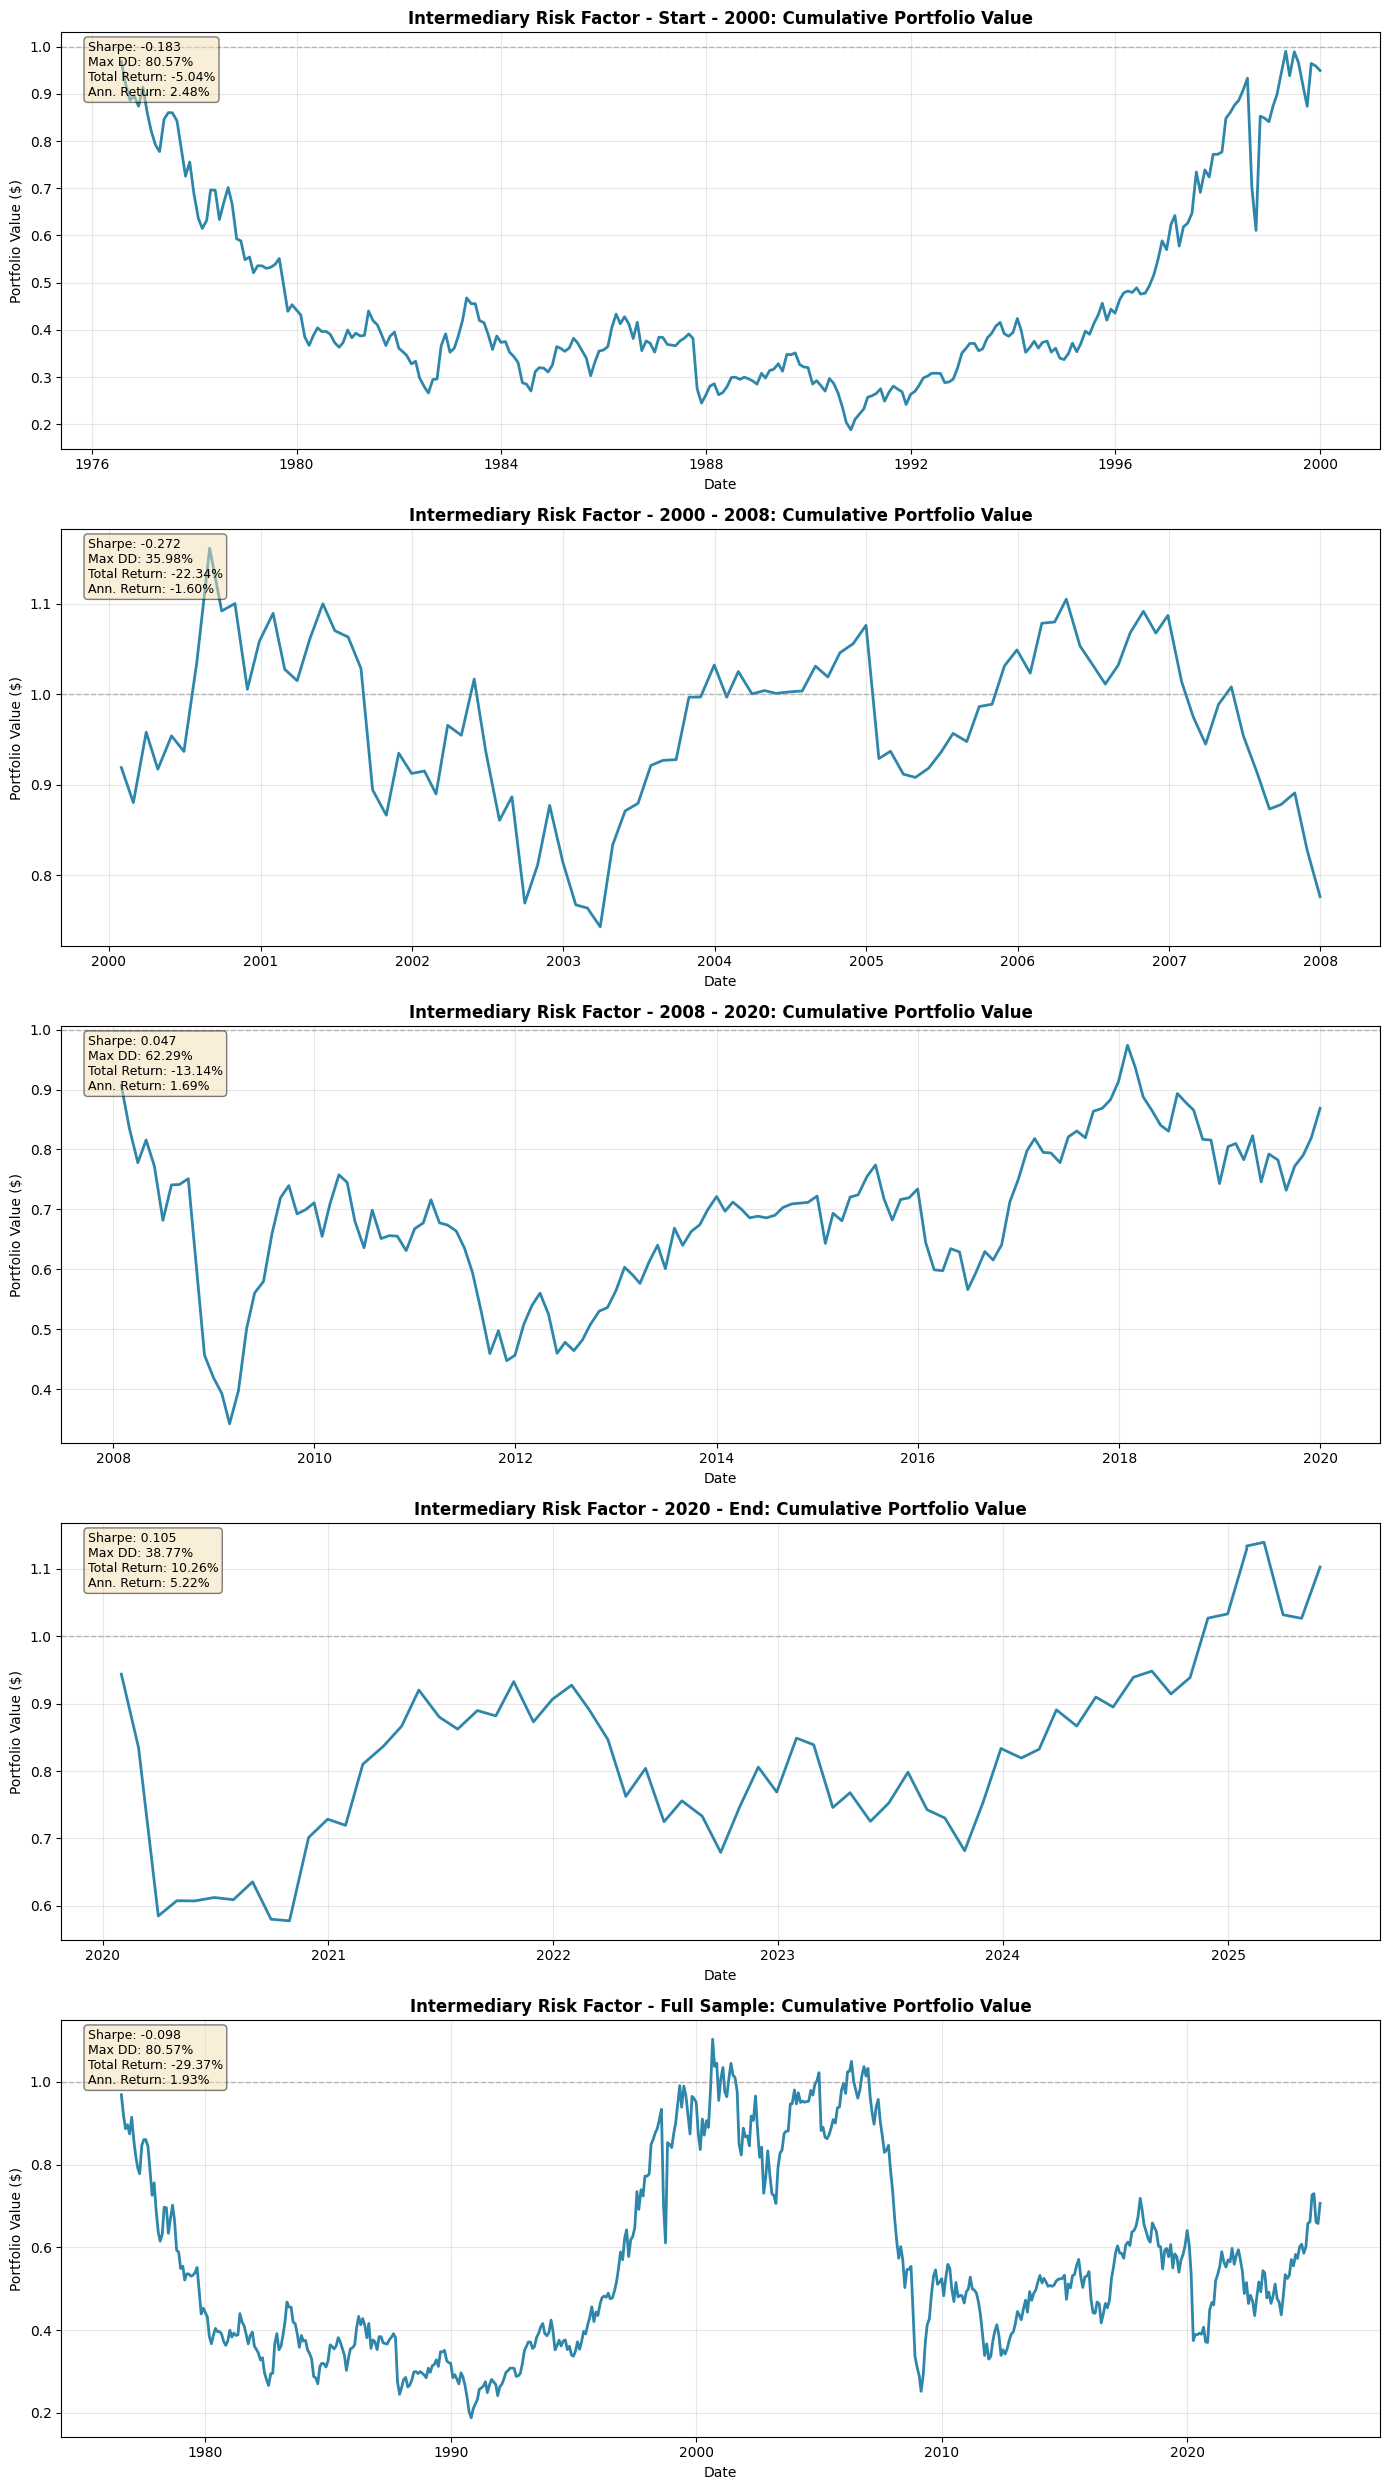

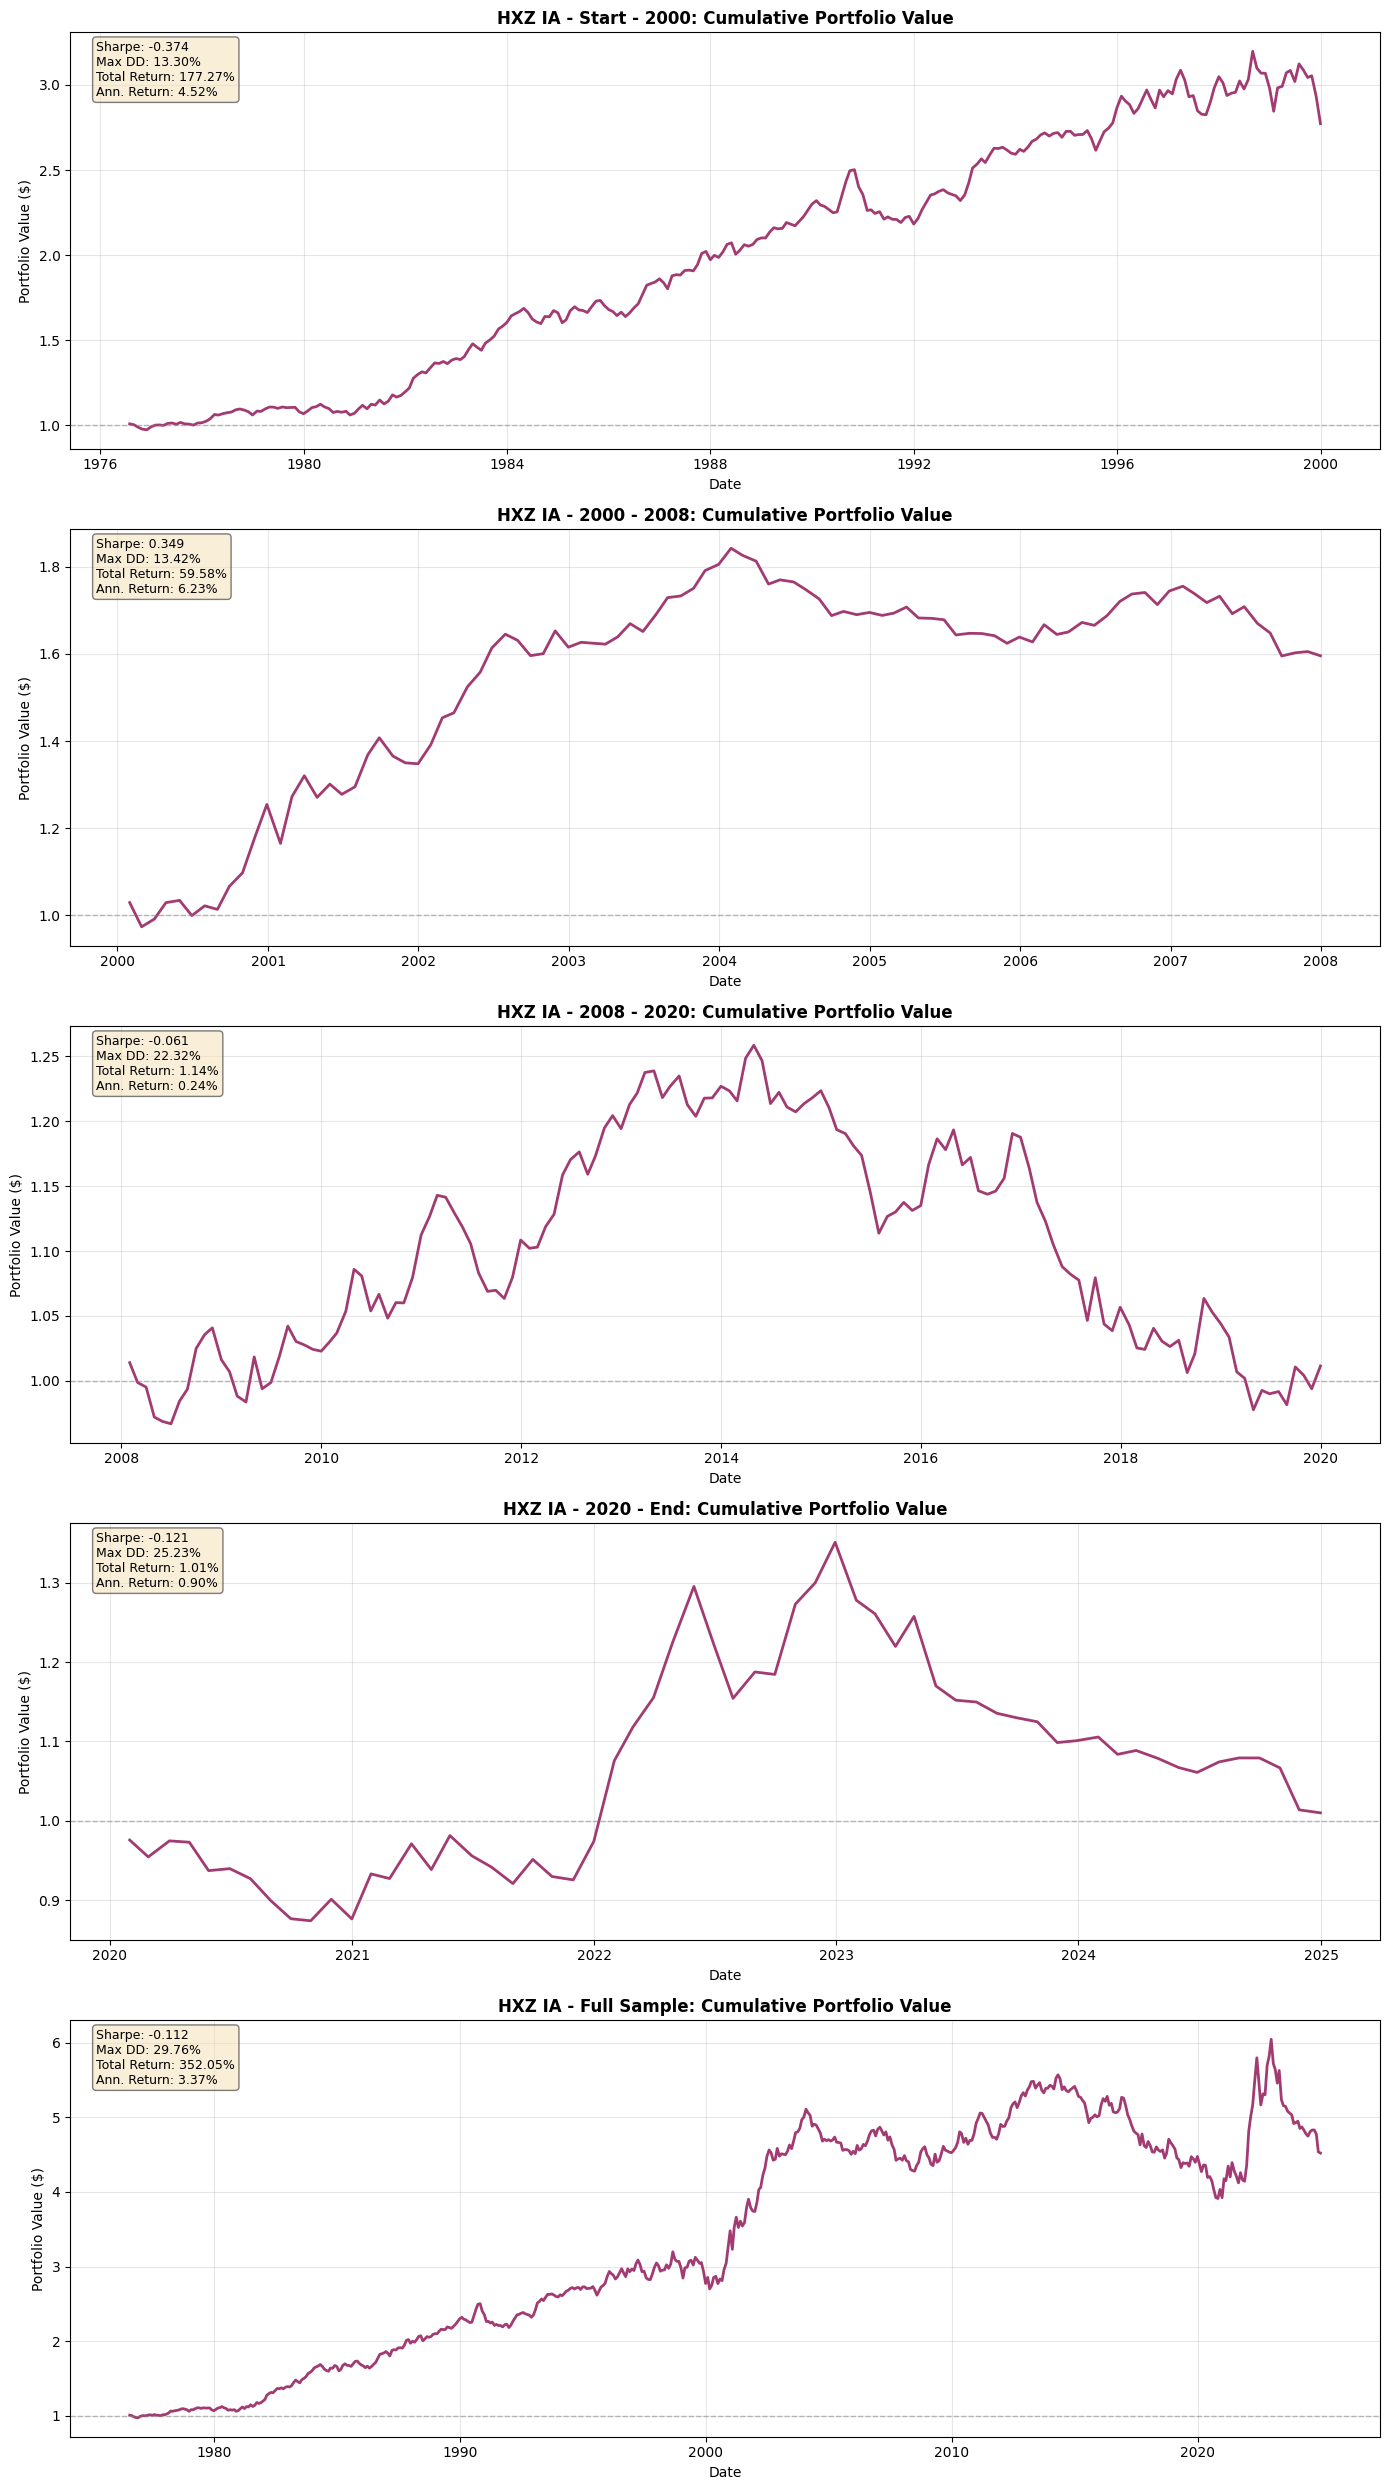

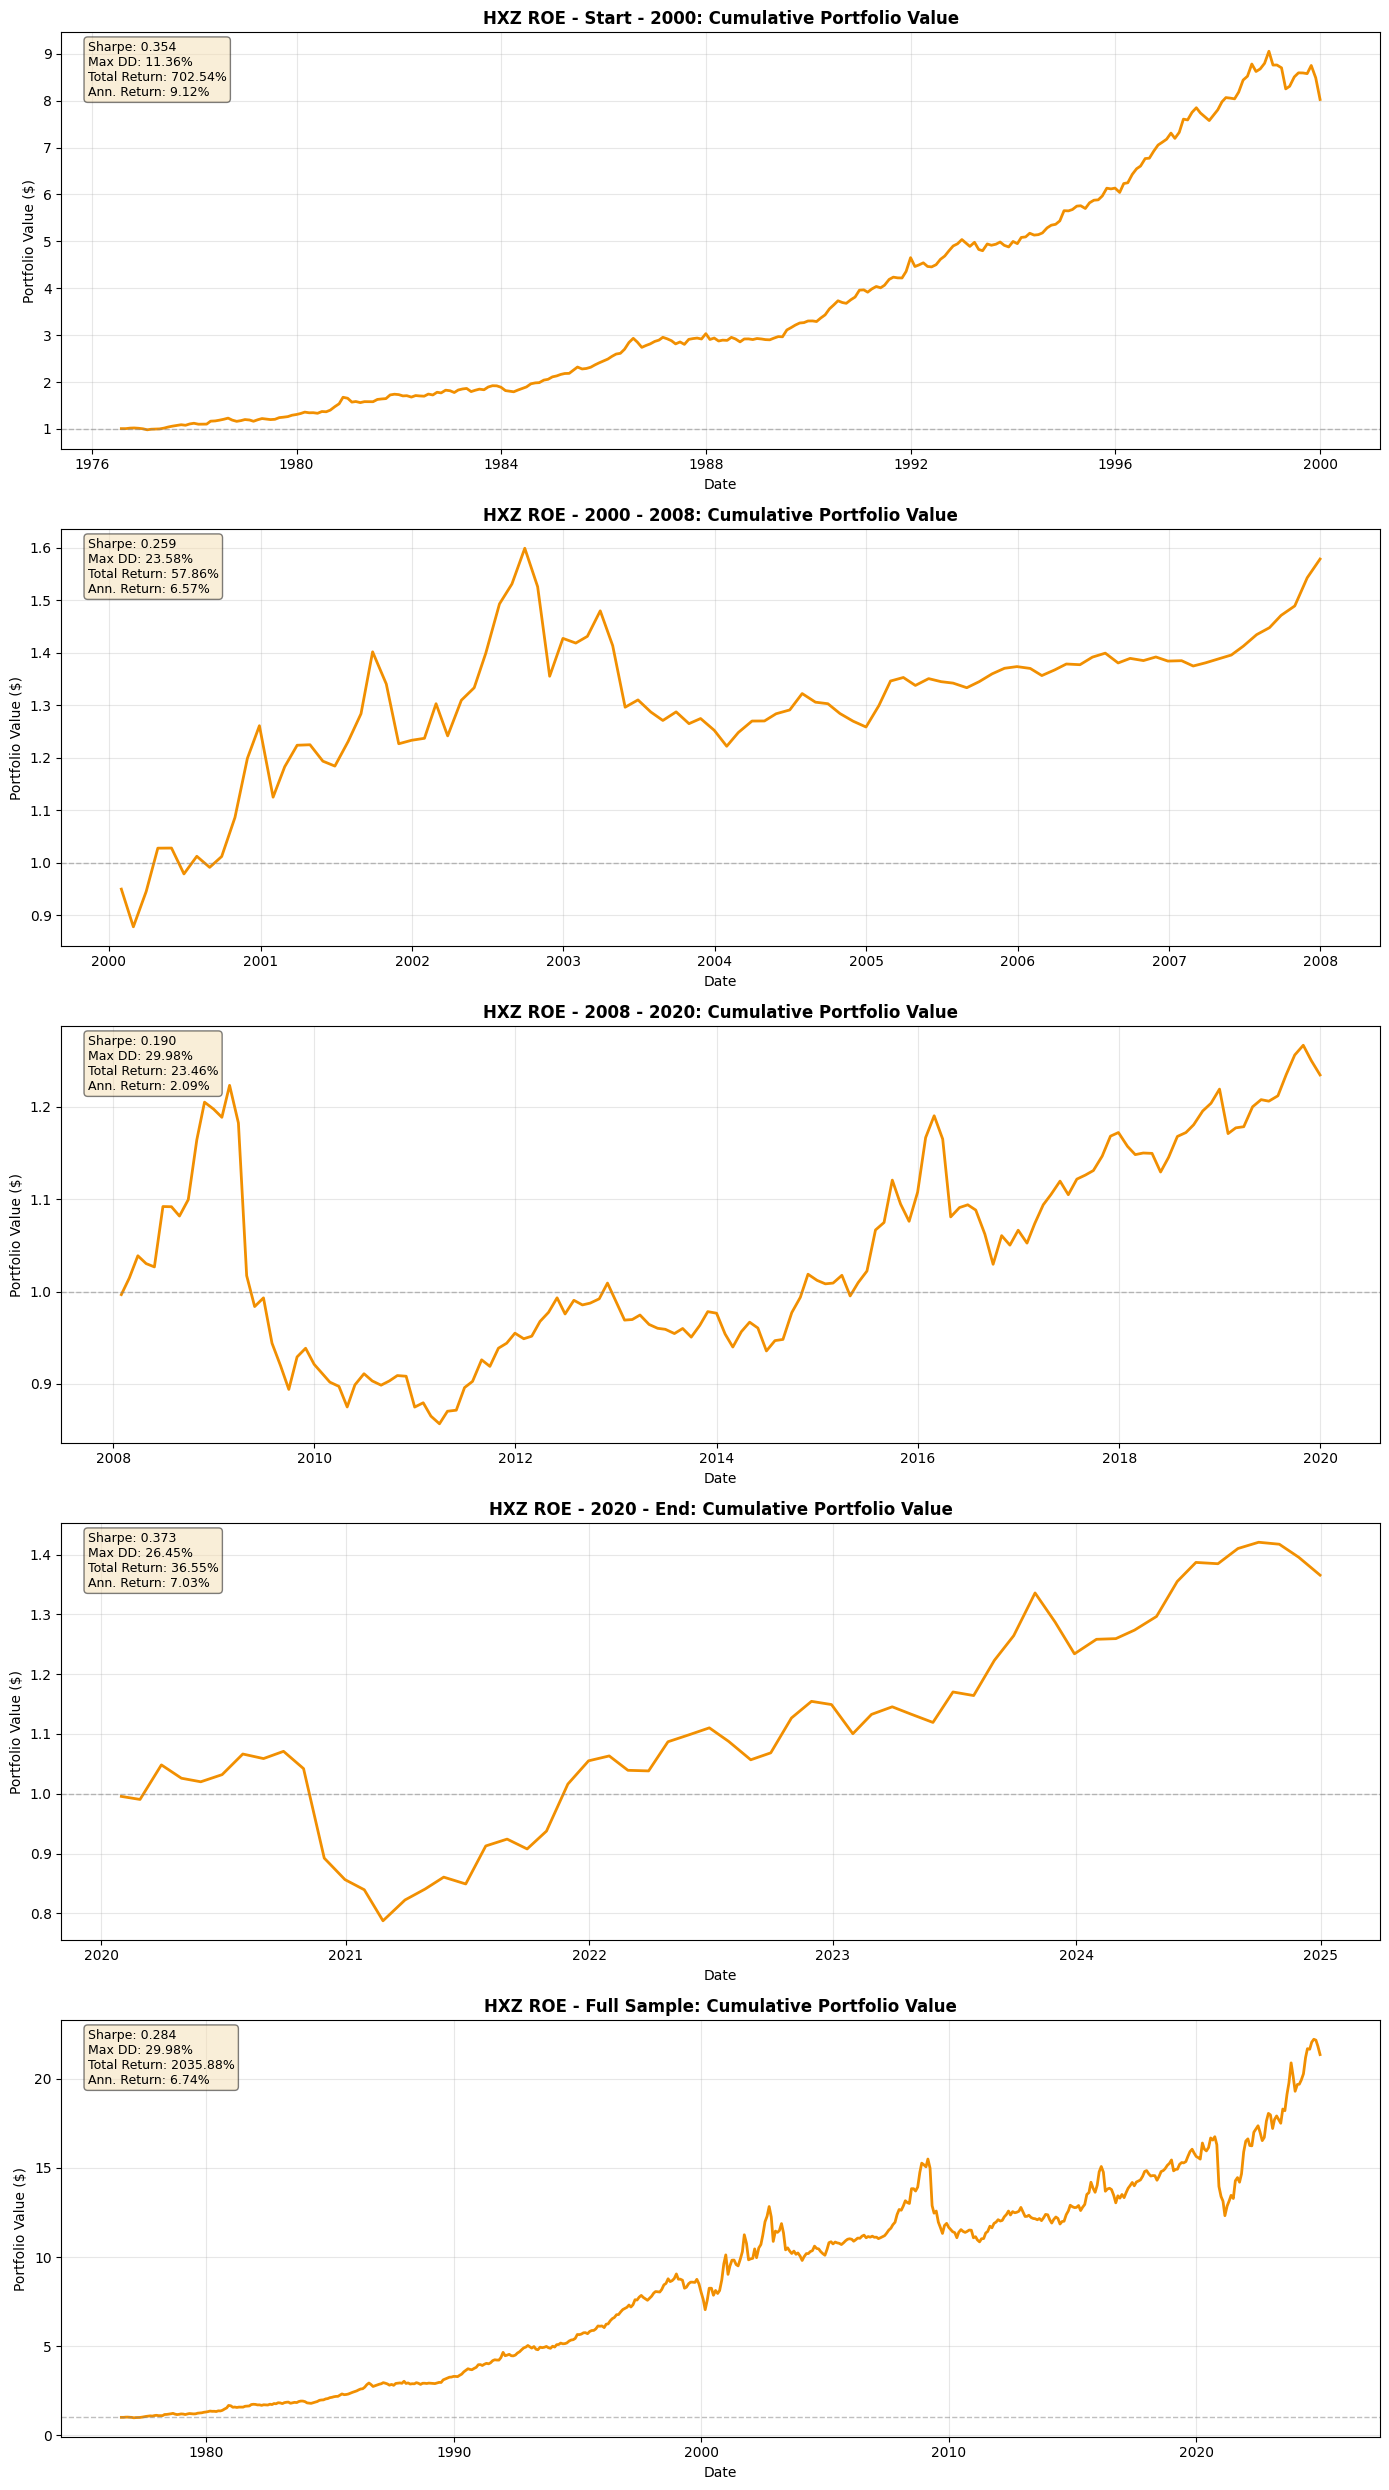

In [213]:
# Create visualizations for all three portfolios
portfolios_to_plot = [
    ('Intermediary Risk Factor', inter_results, '#2E86AB'),
    ('HXZ IA', hxz_ia_results, '#A23B72'),
    ('HXZ ROE', hxz_roe_results, '#F18F01')
]

for portfolio_name, results_dict, color in portfolios_to_plot:
    n_periods = len(results_dict)
    if n_periods == 0:
        continue
        
    fig, axes = plt.subplots(n_periods, 1, figsize=(14, 5 * n_periods))
    
    if n_periods == 1:
        axes = [axes]
    
    for idx, (period_name, result) in enumerate(results_dict.items()):
        results_df = result['results']
        sharpe = result['sharpe_ratio']
        total_ret = result['total_return']
        ann_ret = result['annualized_return']
        max_dd = result['max_drawdown']
        
        # Plot Cumulative Returns / Portfolio Value
        ax = axes[idx]
        ax.plot(results_df.index, results_df['Portfolio_Value'], 
                 linewidth=2, color=color, label=f'{portfolio_name} Portfolio Value')
        ax.axhline(y=1, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Initial Investment ($1)')
        ax.set_title(f'{portfolio_name} - {period_name}: Cumulative Portfolio Value', fontsize=12, fontweight='bold')
        ax.set_xlabel('Date', fontsize=10)
        ax.set_ylabel('Portfolio Value ($)', fontsize=10)
        ax.grid(True, alpha=0.3)
        
        # Add text box with key metrics
        textstr = f'Sharpe: {sharpe:.3f}\nMax DD: {max_dd:.2%}\nTotal Return: {total_ret:.2%}\nAnn. Return: {ann_ret:.2%}'
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=9,
                 verticalalignment='top', bbox=props)
        

    
    plt.tight_layout()
    plt.show()


In [214]:
# Ensure Date index is datetime for QMJ
if not isinstance(qmj.index, pd.DatetimeIndex):
    qmj.index = pd.to_datetime(qmj.index)

# Run full sample backtest for QMJ
print("=" * 80)
print("FULL SAMPLE BACKTEST - QMJ")
print("=" * 80)

qmj_full = run_portfolio_backtest(qmj, rf, "QMJ", period_name="Full Sample")


FULL SAMPLE BACKTEST - QMJ
QMJ Backtest Results - Full Sample

Period: 1976-07-30 to 2025-07-31
Number of periods: 589

--- Performance Statistics ---
Mean Monthly Return:     0.3957%
Std Monthly Return:      2.4185%
Mean Risk-Free Rate:     0.3476%

--- Annualized Statistics ---
Annualized Return:       4.7482%
Annualized Volatility:   8.3779%
Annualized Risk-Free:    4.1711%

--- Risk-Adjusted Metrics ---
Sharpe Ratio:            0.0689
Max Drawdown:            28.2064%
Total Return:            763.0238%
Final Portfolio Value:   $8.63 (from $1 initial)



In [215]:
# Run period-specific backtests for QMJ
periods = [
    {'start': None, 'end': '1999-12-31', 'name': 'Start - 2000'},
    {'start': '2000-01-01', 'end': '2007-12-31', 'name': '2000 - 2008'},
    {'start': '2008-01-01', 'end': '2019-12-31', 'name': '2008 - 2020'},
    {'start': '2020-01-01', 'end': None, 'name': '2020 - End'}
]

qmj_results = {}

for period in periods:
    print(f"\n{'='*80}")
    print(f"PERIOD: {period['name']}")
    print(f"{'='*80}\n")
    
    qmj_result = run_portfolio_backtest(qmj, rf, "QMJ", period['start'], period['end'], period['name'])
    if qmj_result:
        qmj_results[period['name']] = qmj_result

# Add full sample to results dict
if qmj_full:
    qmj_results['Full Sample'] = qmj_full



PERIOD: Start - 2000

QMJ Backtest Results - Start - 2000

Period: 1976-07-30 to 1999-12-31
Number of periods: 282

--- Performance Statistics ---
Mean Monthly Return:     0.4093%
Std Monthly Return:      1.6555%
Mean Risk-Free Rate:     0.5608%

--- Annualized Statistics ---
Annualized Return:       4.9120%
Annualized Volatility:   5.7348%
Annualized Risk-Free:    6.7294%

--- Risk-Adjusted Metrics ---
Sharpe Ratio:            -0.3169
Max Drawdown:            16.5015%
Total Return:            204.6023%
Final Portfolio Value:   $3.05 (from $1 initial)


PERIOD: 2000 - 2008

QMJ Backtest Results - 2000 - 2008

Period: 2000-01-31 to 2007-12-31
Number of periods: 96

--- Performance Statistics ---
Mean Monthly Return:     0.5063%
Std Monthly Return:      3.1746%
Mean Risk-Free Rate:     0.2659%

--- Annualized Statistics ---
Annualized Return:       6.0759%
Annualized Volatility:   10.9973%
Annualized Risk-Free:    3.1912%

--- Risk-Adjusted Metrics ---
Sharpe Ratio:            0.2623
Ma

In [216]:
# Create summary table for QMJ
qmj_summary = create_summary_table(qmj_results, "QMJ")

print("\n" + "=" * 100)
print("QMJ PORTFOLIO - SUMMARY")
print("=" * 100)
print(qmj_summary.to_string(index=False))
print("=" * 100)



QMJ PORTFOLIO - SUMMARY
      Period Start Date   End Date Annualized Return Annualized Volatility Sharpe Ratio Max Drawdown Total Return Final Value ($)
Start - 2000 1976-07-30 1999-12-31             4.91%                 5.73%       -0.317       16.50%      204.60%           $3.05
 2000 - 2008 2000-01-31 2007-12-31             6.08%                11.00%        0.262       23.92%       54.90%           $1.55
 2008 - 2020 2008-01-31 2019-12-31             4.96%                 8.97%        0.489       28.21%       72.67%           $1.73
  2020 - End 2020-01-31 2025-07-31             1.71%                11.65%       -0.073       20.27%        5.93%           $1.06
 Full Sample 1976-07-30 2025-07-31             4.75%                 8.38%        0.069       28.21%      763.02%           $8.63


In [217]:
# Calculate correlations with SPX and RUT for QMJ
qmj_normalized = normalize_portfolio_dates(qmj)

print("\n" + "=" * 80)
print("QMJ PORTFOLIO - CORRELATIONS")
print("=" * 80)

qmj_full_corr = calculate_correlations(
    qmj_normalized,
    spx_df_normalized['SPX_Return'],
    rut_df_normalized['RUT_Return'],
    period_name="Full Sample"
)

qmj_correlations = []
if qmj_full_corr:
    qmj_correlations.append(qmj_full_corr)
    print(f"\nFull Sample:")
    print(f"  Correlation QMJ vs SPX: {qmj_full_corr['corr_rmw_spx']:.4f}")
    print(f"  Correlation QMJ vs RUT: {qmj_full_corr['corr_rmw_rut']:.4f}")

for period in periods:
    corr_result = calculate_correlations(
        qmj_normalized,
        spx_df_normalized['SPX_Return'],
        rut_df_normalized['RUT_Return'],
        start_date=period['start'],
        end_date=period['end'],
        period_name=period['name']
    )
    if corr_result:
        qmj_correlations.append(corr_result)
        print(f"\n{period['name']}:")
        print(f"  Correlation QMJ vs SPX: {corr_result['corr_rmw_spx']:.4f}")
        print(f"  Correlation QMJ vs RUT: {corr_result['corr_rmw_rut']:.4f}")



QMJ PORTFOLIO - CORRELATIONS

Full Sample:
  Correlation QMJ vs SPX: -0.5182
  Correlation QMJ vs RUT: -0.6652

Start - 2000:
  Correlation QMJ vs SPX: -0.3551
  Correlation QMJ vs RUT: -0.5717

2000 - 2008:
  Correlation QMJ vs SPX: -0.6370
  Correlation QMJ vs RUT: -0.8127

2008 - 2020:
  Correlation QMJ vs SPX: -0.6293
  Correlation QMJ vs RUT: -0.6663

2020 - End:
  Correlation QMJ vs SPX: -0.4594
  Correlation QMJ vs RUT: -0.6524


In [218]:
# Create correlation summary table for QMJ
qmj_corr_df = create_correlation_summary(qmj_correlations, 'QMJ')

print("\n" + "=" * 100)
print("CORRELATION SUMMARY - QMJ")
print("=" * 100)
print(qmj_corr_df.to_string(index=False))
print("=" * 100)



CORRELATION SUMMARY - QMJ
      Period Start Date   End Date  N Observations QMJ vs SPX QMJ vs RUT
 Full Sample 1987-10-31 2025-07-31             454    -0.5182    -0.6652
Start - 2000 1987-10-31 1999-12-31             147    -0.3551    -0.5717
 2000 - 2008 2000-01-31 2007-12-31              96    -0.6370    -0.8127
 2008 - 2020 2008-01-31 2019-12-31             144    -0.6293    -0.6663
  2020 - End 2020-01-31 2025-07-31              67    -0.4594    -0.6524


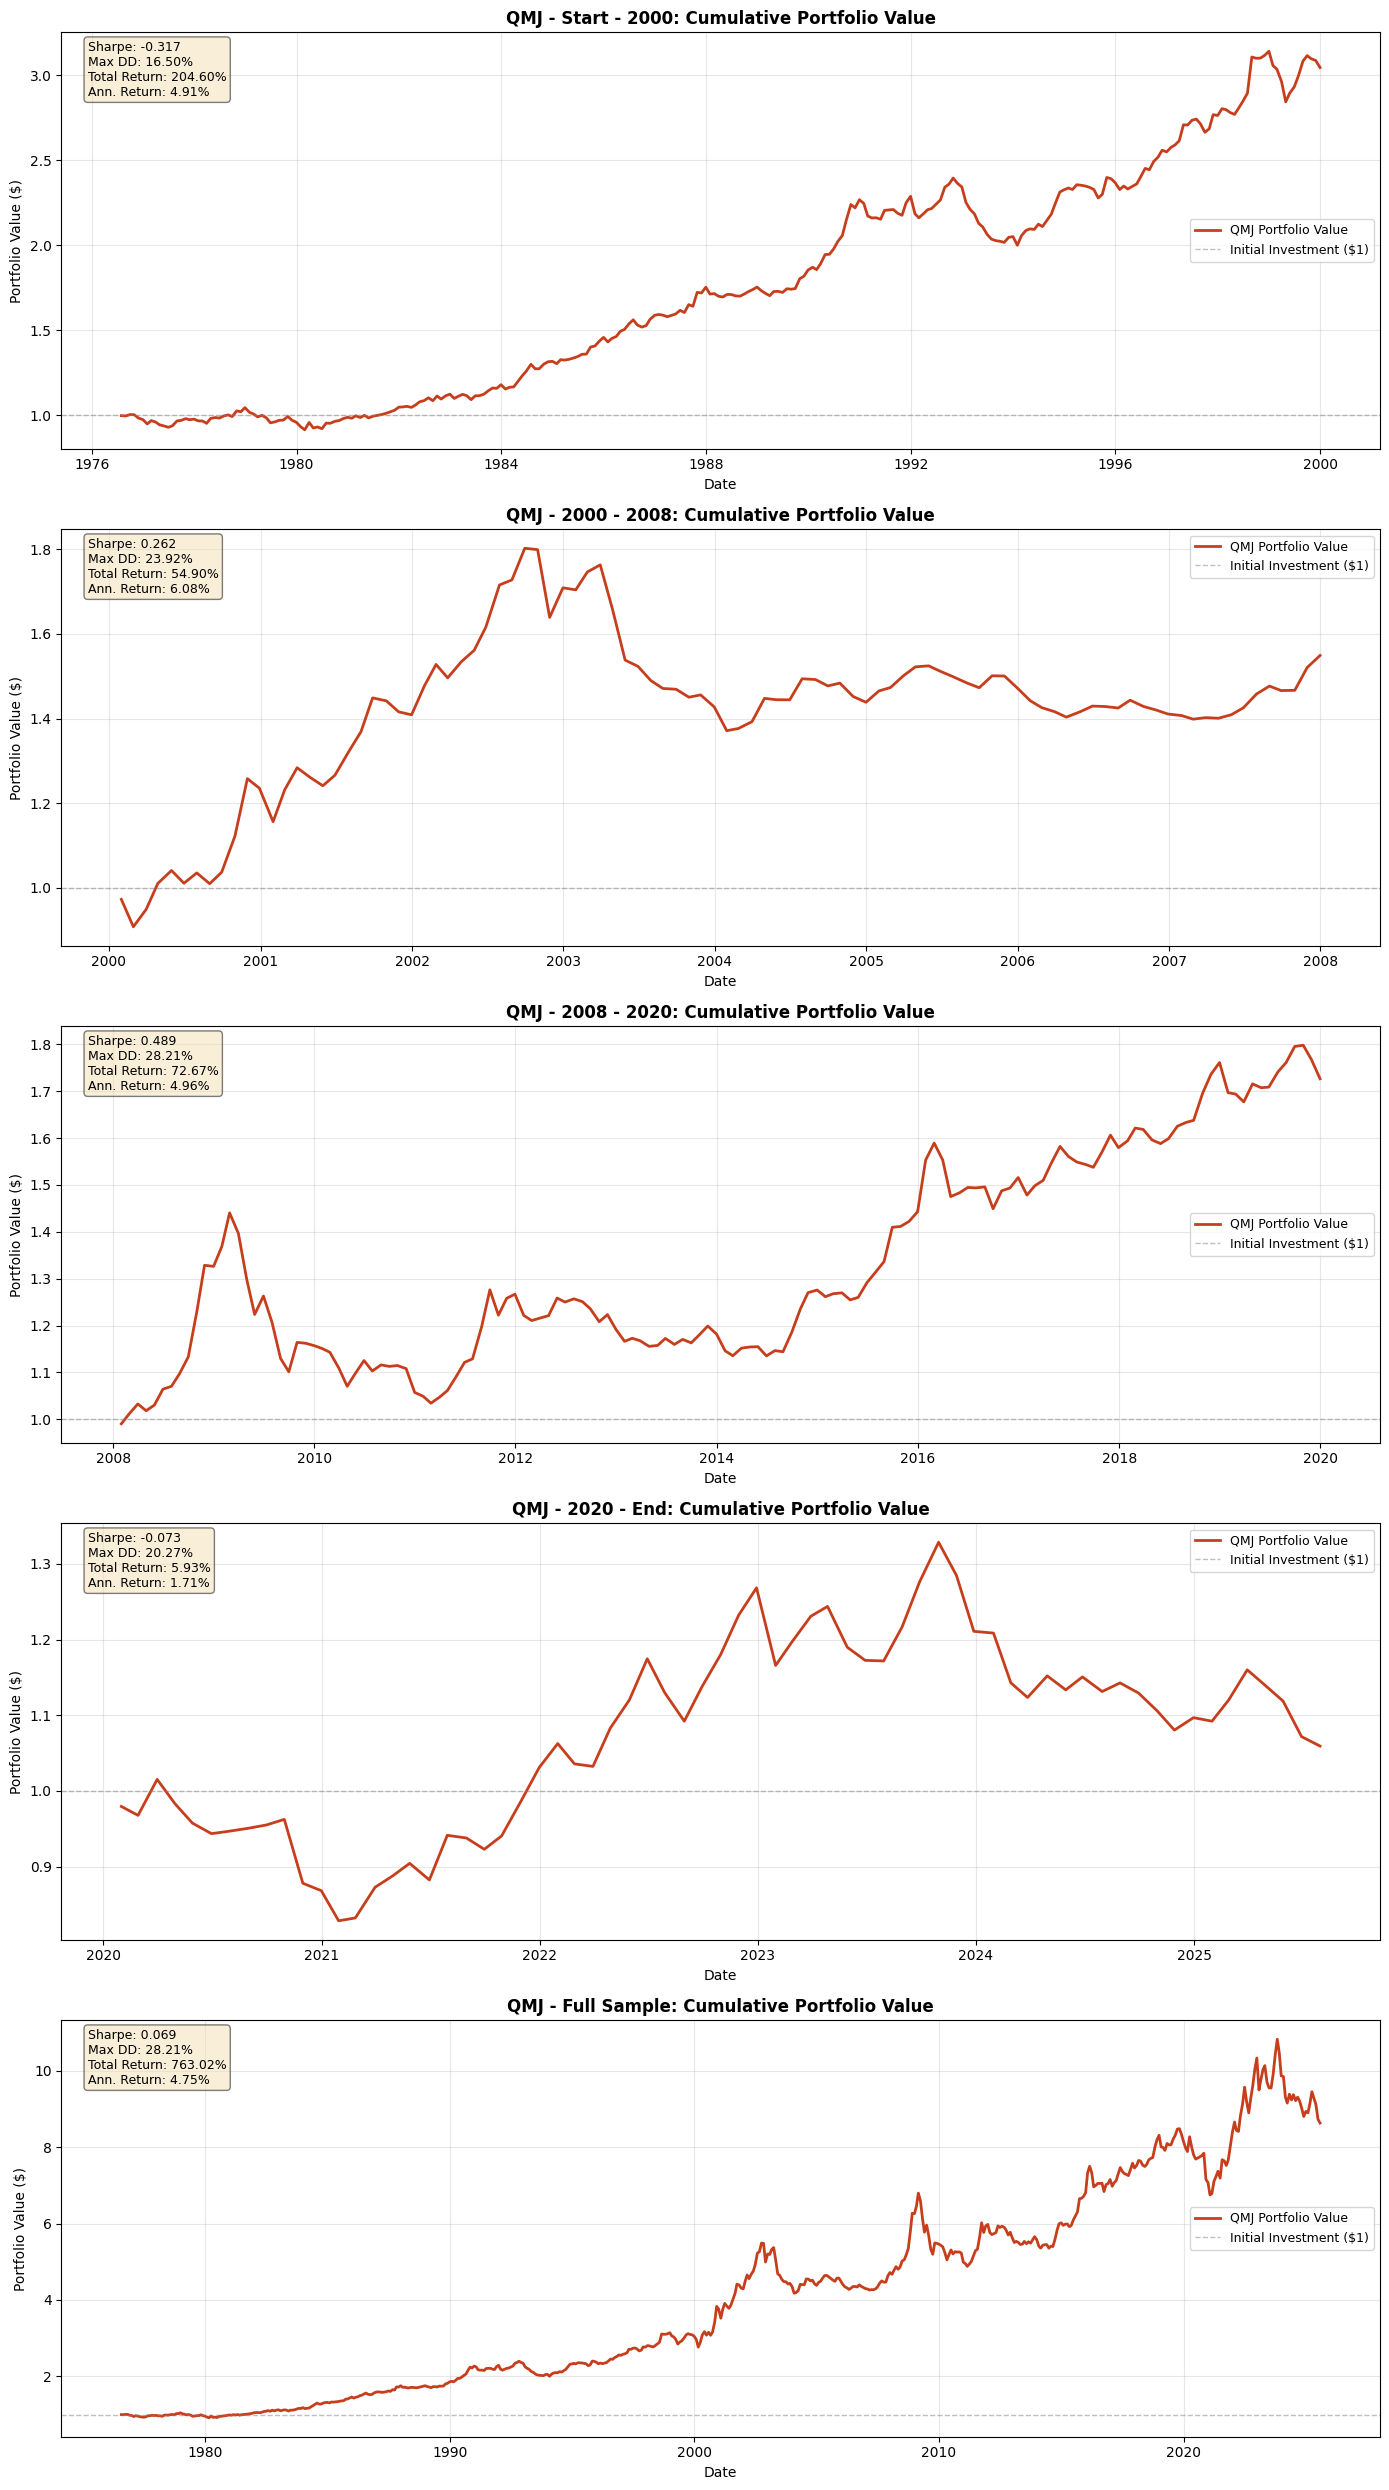

In [219]:
# Create visualization for QMJ
n_periods = len(qmj_results)
if n_periods > 0:
    fig, axes = plt.subplots(n_periods, 1, figsize=(14, 5 * n_periods))
    
    if n_periods == 1:
        axes = [axes]
    
    color = '#C73E1D'  # Different color for QMJ
    
    for idx, (period_name, result) in enumerate(qmj_results.items()):
        results_df = result['results']
        sharpe = result['sharpe_ratio']
        total_ret = result['total_return']
        ann_ret = result['annualized_return']
        max_dd = result['max_drawdown']
        
        # Plot Cumulative Returns / Portfolio Value
        ax = axes[idx]
        ax.plot(results_df.index, results_df['Portfolio_Value'], 
                 linewidth=2, color=color, label='QMJ Portfolio Value')
        ax.axhline(y=1, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Initial Investment ($1)')
        ax.set_title(f'QMJ - {period_name}: Cumulative Portfolio Value', fontsize=12, fontweight='bold')
        ax.set_xlabel('Date', fontsize=10)
        ax.set_ylabel('Portfolio Value ($)', fontsize=10)
        ax.legend(loc='best', fontsize=9)
        ax.grid(True, alpha=0.3)
        
        # Add text box with key metrics
        textstr = f'Sharpe: {sharpe:.3f}\nMax DD: {max_dd:.2%}\nTotal Return: {total_ret:.2%}\nAnn. Return: {ann_ret:.2%}'
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=9,
                 verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    plt.show()


In [ ]:
from scipy import stats
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# Function to run linear factor decomposition
def factor_decomposition(spy_returns, portfolio_returns, portfolio_name, start_date=None, end_date=None, period_name=""):
    """
    Run linear factor decomposition: SPY = alpha + beta * Portfolio + error
    
    Parameters:
    -----------
    spy_returns : pd.Series
        SPY returns
    portfolio_returns : pd.Series
        Portfolio returns
    portfolio_name : str
        Name of the portfolio
    start_date : str or None
        Start date for filtering
    end_date : str or None
        End date for filtering
    period_name : str
        Name of the period
    
    Returns:
    --------
    dict : Dictionary with regression results
    """
    # Filter by date range if provided
    if start_date is not None:
        start_date = pd.to_datetime(start_date)
        spy_returns = spy_returns[spy_returns.index >= start_date]
        portfolio_returns = portfolio_returns[portfolio_returns.index >= start_date]
    
    if end_date is not None:
        end_date = pd.to_datetime(end_date)
        spy_returns = spy_returns[spy_returns.index <= end_date]
        portfolio_returns = portfolio_returns[portfolio_returns.index <= end_date]
    
    # Align on common dates - handle potential duplicates
    common_dates = spy_returns.index.intersection(portfolio_returns.index)
    
    if len(common_dates) < 2:
        print(f"Warning: Insufficient common dates for {portfolio_name} - {period_name}")
        return None
    
    # Remove duplicates by taking the last value for each date
    spy_clean = spy_returns[~spy_returns.index.duplicated(keep='last')]
    portfolio_clean = portfolio_returns[~portfolio_returns.index.duplicated(keep='last')]
    
    # Get common dates again after removing duplicates
    common_dates_clean = spy_clean.index.intersection(portfolio_clean.index)
    
    if len(common_dates_clean) < 2:
        print(f"Warning: Insufficient common dates after deduplication for {portfolio_name} - {period_name}")
        return None
    
    # Align the series
    spy_aligned_series = spy_clean.reindex(common_dates_clean)
    portfolio_aligned_series = portfolio_clean.reindex(common_dates_clean)
    
    # Remove any NaN values - this ensures both arrays have the same length
    valid_mask = ~(spy_aligned_series.isna() | portfolio_aligned_series.isna())
    spy_aligned = spy_aligned_series[valid_mask].values
    portfolio_aligned = portfolio_aligned_series[valid_mask].values
    
    if len(spy_aligned) < 2:
        print(f"Warning: Insufficient valid data for {portfolio_name} - {period_name}")
        return None
    
    # Run OLS regression: Portfolio = alpha + beta * SPY
    # Using scipy.stats.linregress for simple regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(spy_aligned, portfolio_aligned)
    
    # Calculate additional statistics
    n = len(spy_aligned)
    alpha = intercept
    beta = slope
    
    # Calculate R-squared
    r_squared = r_value ** 2
    
    # Calculate t-statistics
    # Standard error of intercept and slope
    x_mean = np.mean(portfolio_aligned)
    x_var = np.var(portfolio_aligned, ddof=1)
    residuals = portfolio_aligned - (alpha + beta * spy_aligned)
    mse = np.sum(residuals ** 2) / (n - 2)
    
    se_alpha = np.sqrt(mse * (1/n + x_mean**2 / (x_var * (n - 1))))
    se_beta = std_err
    
    t_stat_alpha = alpha / se_alpha if se_alpha > 0 else np.nan
    t_stat_beta = beta / se_beta if se_beta > 0 else np.nan
    
    # Calculate p-values for t-stats
    p_value_alpha = 2 * (1 - stats.t.cdf(abs(t_stat_alpha), n - 2)) if not np.isnan(t_stat_alpha) else np.nan
    p_value_beta = 2 * (1 - stats.t.cdf(abs(t_stat_beta), n - 2)) if not np.isnan(t_stat_beta) else np.nan
    
    # Annualized alpha (multiply by 12 for monthly data)
    alpha_annualized = alpha * 12
    
    return {
        'portfolio_name': portfolio_name,
        'period_name': period_name,
        'start_date': common_dates_clean[0] if len(common_dates_clean) > 0 else None,
        'end_date': common_dates_clean[-1] if len(common_dates_clean) > 0 else None,
        'n_observations': n,
        'alpha': alpha,
        'alpha_annualized': alpha_annualized,
        'beta': beta,
        'r_squared': r_squared,
        't_stat_alpha': t_stat_alpha,
        't_stat_beta': t_stat_beta,
        'p_value_alpha': p_value_alpha,
        'p_value_beta': p_value_beta,
        'se_alpha': se_alpha,
        'se_beta': se_beta
    }

# Normalize all portfolio dates for alignment with SPY
rmw_for_decomp = normalize_portfolio_dates(rmw)
inter_for_decomp = normalize_portfolio_dates(inter)
hxz_ia_for_decomp = normalize_portfolio_dates(hxz_ia)
hxz_roe_for_decomp = normalize_portfolio_dates(hxz_roe)
qmj_for_decomp = normalize_portfolio_dates(qmj)

portfolios = {
    'RMW': rmw_for_decomp,
    'Intermediary': inter_for_decomp,
    'HXZ_IA': hxz_ia_for_decomp,
    'HXZ_ROE': hxz_roe_for_decomp,
    'QMJ': qmj_for_decomp
}

print("=" * 100)
print("LINEAR FACTOR DECOMPOSITION: Portfolio = alpha + beta * SPY")
print("=" * 100)


LINEAR FACTOR DECOMPOSITION: SPY = alpha + beta * Portfolio


In [221]:
# Run factor decomposition for full sample
print("\n" + "=" * 100)
print("FULL SAMPLE FACTOR DECOMPOSITION")
print("=" * 100)

full_sample_results = {}
for portfolio_name, portfolio_returns in portfolios.items():
    result = factor_decomposition(
        spy_df_normalized['SPY_Return'],
        portfolio_returns,
        portfolio_name,
        period_name="Full Sample"
    )
    if result:
        full_sample_results[portfolio_name] = result
        print(f"\n{portfolio_name}:")
        print(f"  Period: {result['start_date'].strftime('%Y-%m-%d')} to {result['end_date'].strftime('%Y-%m-%d')}")
        print(f"  Observations: {result['n_observations']}")
        print(f"  Alpha (monthly): {result['alpha']:.6f} ({result['alpha_annualized']:.4%} annualized)")
        print(f"  Beta: {result['beta']:.4f}")
        print(f"  R-squared: {result['r_squared']:.4f}")
        print(f"  t-stat (alpha): {result['t_stat_alpha']:.4f} (p-value: {result['p_value_alpha']:.4f})")
        print(f"  t-stat (beta): {result['t_stat_beta']:.4f} (p-value: {result['p_value_beta']:.4f})")



FULL SAMPLE FACTOR DECOMPOSITION

RMW:
  Period: 1993-02-28 to 2025-08-31
  Observations: 391
  Alpha (monthly): 0.004841 (5.8092% annualized)
  Beta: -0.1613
  R-squared: 0.0662
  t-stat (alpha): 3.6671 (p-value: 0.0003)
  t-stat (beta): -5.2517 (p-value: 0.0000)

Intermediary:
  Period: 1993-02-28 to 2025-05-31
  Observations: 388
  Alpha (monthly): -0.006737 (-8.0840% annualized)
  Beta: 1.1416
  R-squared: 0.5418
  t-stat (alpha): -2.9440 (p-value: 0.0034)
  t-stat (beta): 21.3650 (p-value: 0.0000)

HXZ_IA:
  Period: 1993-02-28 to 2024-12-31
  Observations: 383
  Alpha (monthly): 0.003123 (3.7475% annualized)
  Beta: -0.1334
  R-squared: 0.0619
  t-stat (alpha): 2.7352 (p-value: 0.0065)
  t-stat (beta): -5.0148 (p-value: 0.0000)

HXZ_ROE:
  Period: 1993-02-28 to 2024-12-31
  Observations: 383
  Alpha (monthly): 0.006593 (7.9116% annualized)
  Beta: -0.2550
  R-squared: 0.1439
  t-stat (alpha): 4.7849 (p-value: 0.0000)
  t-stat (beta): -8.0024 (p-value: 0.0000)

QMJ:
  Period: 1993

In [222]:
# Run factor decomposition for subsample periods
periods = [
    {'start': None, 'end': '1999-12-31', 'name': 'Start - 2000'},
    {'start': '2000-01-01', 'end': '2007-12-31', 'name': '2000 - 2008'},
    {'start': '2008-01-01', 'end': '2019-12-31', 'name': '2008 - 2020'},
    {'start': '2020-01-01', 'end': None, 'name': '2020 - End'}
]

subsample_results = {period['name']: {} for period in periods}

for period in periods:
    print("\n" + "=" * 100)
    print(f"SUBSAMPLE PERIOD: {period['name']}")
    print("=" * 100)
    
    for portfolio_name, portfolio_returns in portfolios.items():
        result = factor_decomposition(
            spy_df_normalized['SPY_Return'],
            portfolio_returns,
            portfolio_name,
            start_date=period['start'],
            end_date=period['end'],
            period_name=period['name']
        )
        if result:
            subsample_results[period['name']][portfolio_name] = result
            print(f"\n{portfolio_name}:")
            print(f"  Period: {result['start_date'].strftime('%Y-%m-%d')} to {result['end_date'].strftime('%Y-%m-%d')}")
            print(f"  Observations: {result['n_observations']}")
            print(f"  Alpha (monthly): {result['alpha']:.6f} ({result['alpha_annualized']:.4%} annualized)")
            print(f"  Beta: {result['beta']:.4f}")
            print(f"  R-squared: {result['r_squared']:.4f}")
            print(f"  t-stat (alpha): {result['t_stat_alpha']:.4f} (p-value: {result['p_value_alpha']:.4f})")
            print(f"  t-stat (beta): {result['t_stat_beta']:.4f} (p-value: {result['p_value_beta']:.4f})")



SUBSAMPLE PERIOD: Start - 2000

RMW:
  Period: 1993-02-28 to 1999-12-31
  Observations: 83
  Alpha (monthly): 0.001881 (2.2573% annualized)
  Beta: -0.1081
  R-squared: 0.0521
  t-stat (alpha): 0.9984 (p-value: 0.3211)
  t-stat (beta): -2.1095 (p-value: 0.0380)

Intermediary:
  Period: 1993-02-28 to 1999-12-31
  Observations: 83
  Alpha (monthly): -0.007905 (-9.4862% annualized)
  Beta: 1.3014
  R-squared: 0.4544
  t-stat (alpha): -1.3312 (p-value: 0.1869)
  t-stat (beta): 8.2139 (p-value: 0.0000)

HXZ_IA:
  Period: 1993-02-28 to 1999-12-31
  Observations: 83
  Alpha (monthly): 0.006513 (7.8162% annualized)
  Beta: -0.2763
  R-squared: 0.2509
  t-stat (alpha): 3.3259 (p-value: 0.0013)
  t-stat (beta): -5.2080 (p-value: 0.0000)

HXZ_ROE:
  Period: 1993-02-28 to 1999-12-31
  Observations: 83
  Alpha (monthly): 0.006630 (7.9555% annualized)
  Beta: -0.0394
  R-squared: 0.0065
  t-stat (alpha): 3.1641 (p-value: 0.0022)
  t-stat (beta): -0.7281 (p-value: 0.4686)

QMJ:
  Period: 1993-02-28 

In [223]:
# Create summary tables for factor decomposition results
def create_decomp_summary(full_results, subsample_results_dict):
    """Create summary table for factor decomposition"""
    summary_data = []
    
    # Add full sample results
    for portfolio_name, result in full_results.items():
        summary_data.append({
            'Portfolio': portfolio_name,
            'Period': 'Full Sample',
            'Start Date': result['start_date'].strftime('%Y-%m-%d'),
            'End Date': result['end_date'].strftime('%Y-%m-%d'),
            'N Obs': result['n_observations'],
            'Alpha (monthly)': f"{result['alpha']:.6f}",
            'Alpha (annualized)': f"{result['alpha_annualized']:.4%}",
            'Beta': f"{result['beta']:.4f}",
            'R-squared': f"{result['r_squared']:.4f}",
            't-stat (alpha)': f"{result['t_stat_alpha']:.4f}",
            't-stat (beta)': f"{result['t_stat_beta']:.4f}",
            'p-value (alpha)': f"{result['p_value_alpha']:.4f}",
            'p-value (beta)': f"{result['p_value_beta']:.4f}"
        })
    
    # Add subsample results
    for period_name, period_results in subsample_results_dict.items():
        for portfolio_name, result in period_results.items():
            summary_data.append({
                'Portfolio': portfolio_name,
                'Period': period_name,
                'Start Date': result['start_date'].strftime('%Y-%m-%d'),
                'End Date': result['end_date'].strftime('%Y-%m-%d'),
                'N Obs': result['n_observations'],
                'Alpha (monthly)': f"{result['alpha']:.6f}",
                'Alpha (annualized)': f"{result['alpha_annualized']:.4%}",
                'Beta': f"{result['beta']:.4f}",
                'R-squared': f"{result['r_squared']:.4f}",
                't-stat (alpha)': f"{result['t_stat_alpha']:.4f}",
                't-stat (beta)': f"{result['t_stat_beta']:.4f}",
                'p-value (alpha)': f"{result['p_value_alpha']:.4f}",
                'p-value (beta)': f"{result['p_value_beta']:.4f}"
            })
    
    return pd.DataFrame(summary_data)

# Create summary table
decomp_summary = create_decomp_summary(full_sample_results, subsample_results)

print("\n" + "=" * 150)
print("FACTOR DECOMPOSITION SUMMARY TABLE")
print("=" * 150)
print(decomp_summary.to_string(index=False))
print("=" * 150)



FACTOR DECOMPOSITION SUMMARY TABLE
   Portfolio       Period Start Date   End Date  N Obs Alpha (monthly) Alpha (annualized)    Beta R-squared t-stat (alpha) t-stat (beta) p-value (alpha) p-value (beta)
         RMW  Full Sample 1993-02-28 2025-08-31    391        0.004841            5.8092% -0.1613    0.0662         3.6671       -5.2517          0.0003         0.0000
Intermediary  Full Sample 1993-02-28 2025-05-31    388       -0.006737           -8.0840%  1.1416    0.5418        -2.9440       21.3650          0.0034         0.0000
      HXZ_IA  Full Sample 1993-02-28 2024-12-31    383        0.003123            3.7475% -0.1334    0.0619         2.7352       -5.0148          0.0065         0.0000
     HXZ_ROE  Full Sample 1993-02-28 2024-12-31    383        0.006593            7.9116% -0.2550    0.1439         4.7849       -8.0024          0.0000         0.0000
         QMJ  Full Sample 1993-02-28 2025-07-31    390        0.007085            8.5021% -0.3508    0.3003         6.0442  


CORRELATION MATRIX: FIVE FACTORS (Full Sample)

Total common periods: 582
Date range: 1976-07-30 00:00:00 to 2024-12-31 00:00:00

CORRELATION MATRIX (Numerical Values)
                 RMW  Intermediary  HXZ_IA  HXZ_ROE     QMJ     UMD
RMW           1.0000       -0.1469  0.1887   0.6814  0.7048  0.0780
Intermediary -0.1469        1.0000 -0.0790  -0.2395 -0.4516 -0.2965
HXZ_IA        0.1887       -0.0790  1.0000   0.0901  0.1580  0.0163
HXZ_ROE       0.6814       -0.2395  0.0901   1.0000  0.7013  0.4916
QMJ           0.7048       -0.4516  0.1580   0.7013  1.0000  0.2900
UMD           0.0780       -0.2965  0.0163   0.4916  0.2900  1.0000


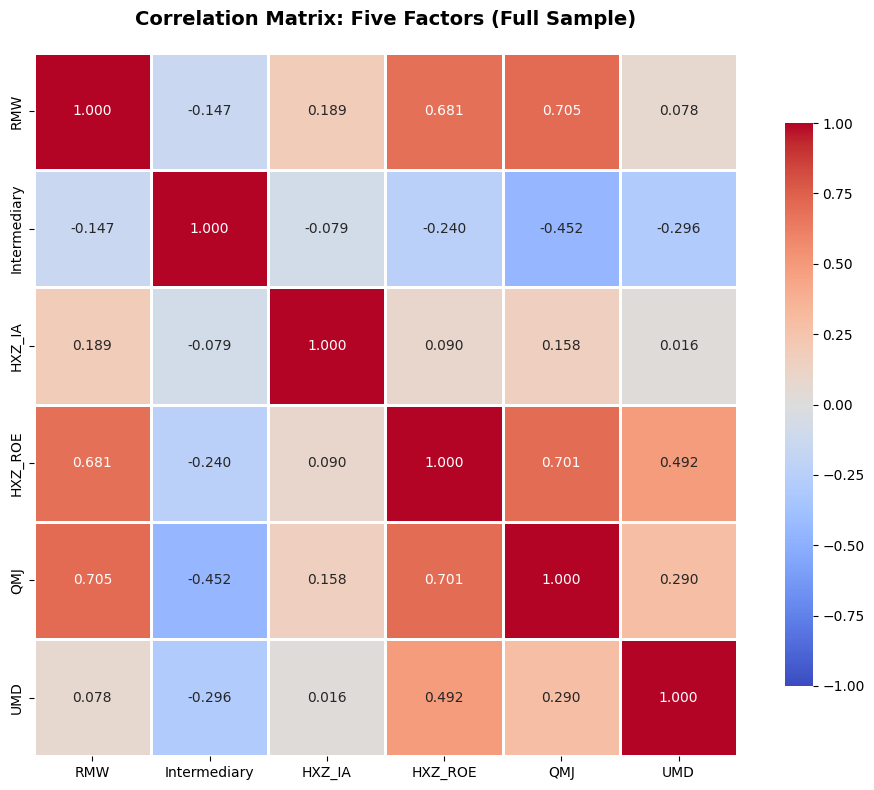

In [236]:
print("\n" + "=" * 100)
print("CORRELATION MATRIX: FIVE FACTORS (Full Sample)")
print("=" * 100)

# Ensure Date index is datetime for all factors and remove duplicates
factors_list = []
factor_names = ['RMW', 'Intermediary', 'HXZ_IA', 'HXZ_ROE', 'QMJ', 'UMD']
factors_data = [rmw, inter, hxz_ia, hxz_roe, qmj, umd]

for name, factor in zip(factor_names, factors_data):
    # Convert to datetime if needed
    if not isinstance(factor.index, pd.DatetimeIndex):
        factor = pd.Series(factor.values, index=pd.to_datetime(factor.index))
    
    # Remove duplicate indices (keep first occurrence)
    factor = factor[~factor.index.duplicated(keep='first')]
    factor.name = name
    factors_list.append(factor)

# Use concat to align all factors (handles different indices better)
factors_df = pd.concat(factors_list, axis=1)

# Remove rows with NaN (where any factor is missing)
factors_df = factors_df.dropna()

print(f"\nTotal common periods: {len(factors_df)}")
print(f"Date range: {factors_df.index[0]} to {factors_df.index[-1]}")

# Calculate correlation matrix
correlation_matrix = factors_df.corr()

# Display correlation matrix as table
print("\n" + "=" * 100)
print("CORRELATION MATRIX (Numerical Values)")
print("=" * 100)
print(correlation_matrix.round(4))

# Create heatmap visualization using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8},
    vmin=-1,
    vmax=1
)
plt.title('Correlation Matrix: Five Factors (Full Sample)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n" + "=" * 100)


In [ ]:
# Run backtest and linear factor decomposition for UMD factor
print("\n" + "=" * 100)
print("UMD FACTOR - BACKTEST AND FACTOR DECOMPOSITION")
print("=" * 100)

# Ensure Date index is datetime
if not isinstance(umd.index, pd.DatetimeIndex):
    umd.index = pd.to_datetime(umd.index)

# Run backtest for UMD
print("\n" + "=" * 80)
print("UMD FACTOR BACKTEST")
print("=" * 80)

umd_backtest_result = run_portfolio_backtest(
    umd,
    rf,
    "UMD",
    period_name="Full Sample"
)

# Run linear factor decomposition for UMD
print("\n" + "=" * 100)
print("UMD FACTOR - LINEAR FACTOR DECOMPOSITION")
print("=" * 100)

# Normalize UMD portfolio dates to month end (to match SPY dates)
umd_normalized = normalize_portfolio_dates(umd)

# Run factor decomposition for full sample
umd_decomp_result = factor_decomposition(
    spy_df_normalized['SPY_Return'],
    umd_normalized,
    "UMD",
    period_name="Full Sample"
)

if umd_decomp_result:
    print(f"\nUMD:")
    print(f"  Period: {umd_decomp_result['start_date'].strftime('%Y-%m-%d')} to {umd_decomp_result['end_date'].strftime('%Y-%m-%d')}")
    print(f"  Observations: {umd_decomp_result['n_observations']}")
    print(f"  Alpha (monthly): {umd_decomp_result['alpha']:.6f} ({umd_decomp_result['alpha_annualized']:.4%} annualized)")
    print(f"  Beta: {umd_decomp_result['beta']:.4f}")
    print(f"  R-squared: {umd_decomp_result['r_squared']:.4f}")
    print(f"  t-stat (alpha): {umd_decomp_result['t_stat_alpha']:.4f} (p-value: {umd_decomp_result['p_value_alpha']:.4f})")
    print(f"  t-stat (beta): {umd_decomp_result['t_stat_beta']:.4f} (p-value: {umd_decomp_result['p_value_beta']:.4f})")
else:
    print("\nError: Could not run factor decomposition for UMD factor")

print("\n" + "=" * 100)



UMD FACTOR - BACKTEST AND FACTOR DECOMPOSITION

UMD FACTOR BACKTEST
UMD Backtest Results - Full Sample

Period: 1976-07-30 to 2025-08-29
Number of periods: 590

--- Performance Statistics ---
Mean Monthly Return:     0.5565%
Std Monthly Return:      4.3297%
Mean Risk-Free Rate:     0.3476%

--- Annualized Statistics ---
Annualized Return:       6.6781%
Annualized Volatility:   14.9987%
Annualized Risk-Free:    4.1717%

--- Risk-Adjusted Metrics ---
Sharpe Ratio:            0.1671
Max Drawdown:            57.8177%
Total Return:            1385.8282%
Final Portfolio Value:   $14.86 (from $1 initial)


UMD FACTOR - LINEAR FACTOR DECOCOMPOSITION

UMD:
  Period: 1993-02-28 to 2025-08-31
  Observations: 391
  Alpha (monthly): 0.007195 (8.6346% annualized)
  Beta: -0.3685
  R-squared: 0.1097
  t-stat (alpha): 3.1592 (p-value: 0.0017)
  t-stat (beta): -6.9232 (p-value: 0.0000)

